# 🐦 Analisis Sentimen Tweet Bahasa Indonesia
## Implementasi TF-IDF Unigram + Linear SVM — **Klasifikasi 3 Kelas**

---

**Nama Proyek:** Klasifikasi Sentimen Teks Tweet Berbahasa Indonesia (Negatif / Netral / Positif)  
**Metode:** TF-IDF Vectorization (Unigram) + Linear Support Vector Machine (LinearSVC)  
**Bahasa:** Python  
**Platform:** Google Colaboratory  

---

## 📌 Deskripsi Proyek

Proyek ini membangun sistem **klasifikasi sentimen tiga kelas** (negatif / netral / positif) terhadap tweet berbahasa Indonesia. Berbeda dari pendekatan biner, klasifikasi tiga kelas memberikan pemahaman yang lebih kaya dan realistis terhadap spektrum opini publik di media sosial.

### Dataset
| Informasi | Detail |
|-----------|--------|
| Nama file | `Indonesian_Sentiment_Twitter_Dataset_Labeled.csv` |
| Format | TSV (Tab-Separated Values) |
| Kolom | `sentimen` (label numerik), `Tweet` (teks) |
| Total data | ~10.806 tweet |
| Label asli | `-1` → negatif, `0` → netral, `1` → positif |
| Target modeling | **3 kelas: negatif, netral, positif** |

### Alur Kerja
```
Dataset TSV → Understanding → EDA (diperluas) → Preprocessing
    → Labeling 3-Kelas → Train-Test Split → TF-IDF → LinearSVC
    → Evaluasi Multi-Class → Confusion Matrix → Error Analysis → Kesimpulan
```

> ⚠️ **Catatan Penting:** Notebook ini menggunakan **Machine Learning Klasik** (bukan Deep Learning). Seluruh pipeline dirancang untuk menangani teks Twitter Bahasa Indonesia yang informal, multi-dialek (Indonesia + Melayu), dan singkat.

---
# 📦 Bagian 1: Import Library

In [ ]:
print("📦 Menginstal library tambahan...")
!pip install PySastrawi -q
!pip install wordcloud -q
print("✅ Instalasi selesai!")

📦 Menginstal library tambahan...
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 210.6/210.6 kB 5.3 MB/s eta 0:00:00
✅ Instalasi selesai!


In [ ]:
import re, string, warnings, time
from collections import Counter

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from wordcloud import WordCloud

import nltk
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords

from Sastrawi.Stemmer.StemmerFactory import StemmerFactory

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.svm import LinearSVC
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix
)

warnings.filterwarnings('ignore')
pd.set_option('display.max_colwidth', 250)
plt.rcParams.update({'figure.figsize': (10, 6), 'font.size': 12,
                     'axes.titlesize': 14, 'axes.titleweight': 'bold'})
sns.set_style("whitegrid")

nltk.download('punkt', quiet=True)
nltk.download('stopwords', quiet=True)
nltk.download('punkt_tab', quiet=True)

print("✅ Semua library berhasil diimport!")
print(f"   pandas  : {pd.__version__}")
print(f"   numpy   : {np.__version__}")
print(f"   sklearn : {__import__('sklearn').__version__}")

✅ Semua library berhasil diimport!
   pandas  : 2.2.2
   numpy   : 2.0.2
   sklearn : 1.6.1


---
# 📂 Bagian 2: Load Dataset

> ⚠️ **Penting:** File `.csv` ini sebenarnya menggunakan **Tab (`\t`) sebagai separator** (format TSV). Wajib menentukan `sep='\t'` saat membacanya. Jika terbaca sebagai satu kolom `sentimen;Tweet`, berarti delimiter tidak terdeteksi — cell berikutnya menangani hal ini otomatis.

In [ ]:
DATASET_PATH = 'Indonesian_Sentiment_Twitter_Dataset_Labeled.csv'

# Coba baca dengan tab separator
df = pd.read_csv(DATASET_PATH, sep='\t')

# ============================================================
# PENANGANAN OTOMATIS: jika file terbaca sebagai 1 kolom
# (hal ini terjadi jika separator aslinya adalah semicolon ';')
# ============================================================
if df.shape[1] == 1:
    print("⚠️  File terbaca sebagai 1 kolom — mendeteksi separator lain...")
    col = df.columns[0]
    # Coba split dengan semicolon
    if ';' in col:
        split_data = df[col].str.split(';', n=1, expand=True)
        df['sentimen'] = pd.to_numeric(split_data[0], errors='coerce')
        df['Tweet'] = split_data[1]
        df = df[['sentimen', 'Tweet']]
        print("✅ Berhasil memisahkan kolom menggunakan ';'")
    else:
        # Coba split dengan comma
        split_data = df[col].str.split(',', n=1, expand=True)
        df['sentimen'] = pd.to_numeric(split_data[0], errors='coerce')
        df['Tweet'] = split_data[1]
        df = df[['sentimen', 'Tweet']]
        print("✅ Berhasil memisahkan kolom menggunakan ','")

# Pastikan tipe data benar
df['sentimen'] = pd.to_numeric(df['sentimen'], errors='coerce')
df['Tweet'] = df['Tweet'].astype(str)
# Hapus baris yang sentimen-nya NaN (header palsu)
df = df.dropna(subset=['sentimen']).reset_index(drop=True)
df['sentimen'] = df['sentimen'].astype(int)

print("\n" + "=" * 60)
print("📊 INFORMASI UMUM DATASET")
print("=" * 60)
print(f"   Jumlah baris  : {df.shape[0]:,} tweet")
print(f"   Jumlah kolom  : {df.shape[1]} kolom")
print(f"   Kolom         : {list(df.columns)}")


📊 INFORMASI UMUM DATASET
   Jumlah baris  : 10,806 tweet
   Jumlah kolom  : 1 kolom
   Kolom         : ['sentimen;Tweet']


In [ ]:
print("📋 10 Baris Pertama Dataset:")
df.head(10)

In [ ]:
print("📋 Info Tipe Data:")
df.info()

In [ ]:
print("\n🔍 Missing Values:")
missing = df.isnull().sum()
missing_pct = (missing / len(df) * 100).round(2)
print(pd.DataFrame({'Missing Count': missing, 'Missing (%)': missing_pct}))
print("\n✅ Tidak ditemukan missing values." if missing.sum() == 0
      else f"\n⚠️  Ditemukan {missing.sum()} missing values.")

In [ ]:
print("\n🔍 Pemeriksaan Data Duplikat:")
n_dup_full  = df.duplicated().sum()
n_dup_tweet = df['Tweet'].duplicated().sum()
print(f"   Duplikat seluruh baris : {n_dup_full:,}")
print(f"   Duplikat kolom Tweet   : {n_dup_tweet:,}")
if n_dup_tweet > 0:
    print(f"\n⚠️  Ditemukan {n_dup_tweet} tweet duplikat — akan dihapus di tahap preprocessing.")
    print("\n   Contoh tweet duplikat:")
    print(df[df['Tweet'].duplicated(keep=False)].sort_values('Tweet').head(4)[['sentimen','Tweet']].to_string())

In [ ]:
print("\n📊 Distribusi Label 'sentimen' (Asli):")
sent_dist = df['sentimen'].value_counts().sort_index()
label_map = {-1: 'Negatif', 0: 'Netral', 1: 'Positif'}
for val, count in sent_dist.items():
    print(f"   Label {val:>2} ({label_map.get(val,'?'):>7}): {count:>5,} tweet ({count/len(df)*100:.2f}%)")
print(f"   {'Total':>15}  : {len(df):>5,} tweet (100.00%)")

---
# 🔍 Bagian 3: Data Understanding

## Deskripsi Kolom

| Kolom | Tipe | Deskripsi | Penggunaan |
|-------|------|-----------|------------|
| `sentimen` | Integer (-1, 0, 1) | Label sentimen anotasi | Hanya untuk membuat label — tidak digunakan saat training |
| `Tweet` | String | Teks tweet berbahasa Indonesia/Melayu | **Fitur/input model** |

## Skema Label (3 Kelas)
| Nilai | Makna | Jumlah |
|-------|-------|--------|
| `-1` | Negatif | ~2.887 tweet |
| `0` | Netral | ~5.327 tweet |
| `1` | Positif | ~2.592 tweet |

## Tantangan Utama Data Twitter Bahasa Indonesia

1. **Teks sangat pendek** — rata-rata ~13 kata, batas 140 karakter
2. **Code-switching** — campur Bahasa Indonesia, Melayu Malaysia, Inggris
3. **Slang & singkatan** — `tp`, `yg`, `bgt`, `gw`, `nak`, `dah`
4. **Dominasi kelas netral** — ~49% data, tantangan klasifikasi multi-class
5. **Ekspresi implisit** — sarkasme, ironi, emosi tersembunyi

In [ ]:
print("📌 Contoh tweet per kelas sentimen:")
print("=" * 70)
for val in [-1, 0, 1]:
    lbl = {-1:'NEGATIF (-1)', 0:'NETRAL (0)', 1:'POSITIF (1)'}[val]
    samples = df[df['sentimen']==val]['Tweet'].head(3).tolist()
    print(f"\n===== {lbl} =====")
    for i, s in enumerate(samples, 1):
        print(f"  [{i}] {s[:140]}")

---
# 📊 Bagian 4: Exploratory Data Analysis (EDA)

EDA dilakukan secara menyeluruh dan diperluas dengan beberapa visualisasi tambahan:

- **A.** Distribusi Label Sentimen (Raw)
- **B.** Distribusi Panjang Tweet (karakter & kata)
- **C.** Bag of Words — Keseluruhan Dataset (Sebelum Preprocessing)
- **D.** Bag of Words — Per Kelas Sentimen
- **E.** Word Cloud — Per Kelas Sentimen (Setelah Preprocessing)
- **F.** Top Frequent Words — Per Kelas Sentimen (Setelah Preprocessing)
- **G.** Distribusi Sentimen Final (Setelah Labeling 3 Kelas)

In [ ]:
# ============================================================
# EDA A: DISTRIBUSI LABEL SENTIMEN (RAW)
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

sent_counts = df['sentimen'].value_counts().sort_index()
tick_labels = ['Negatif\n(-1)', 'Netral\n(0)', 'Positif\n(1)']
bar_colors  = ['#EF5350', '#90CAF9', '#1565C0']

bars = axes[0].bar(tick_labels, sent_counts.values, color=bar_colors,
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, sent_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2., bar.get_height() + 30,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Label Sentimen (3 Kelas)', fontweight='bold')
axes[0].set_xlabel('Kelas Sentimen')
axes[0].set_ylabel('Jumlah Tweet')
axes[0].set_ylim(0, max(sent_counts.values) * 1.25)

pie_labels = [f'{tick_labels[i].replace(chr(10)," ")} ({v:,})'
              for i, v in enumerate(sent_counts.values)]
wedges, texts, autotexts = axes[1].pie(
    sent_counts.values, labels=pie_labels, autopct='%1.1f%%',
    colors=bar_colors, startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':3,'width':0.65})
for at in autotexts:
    at.set_fontweight('bold'); at.set_fontsize(11)
axes[1].set_title('Proporsi Kelas Sentimen', fontweight='bold')

plt.suptitle('Distribusi Label Sentimen Dataset Twitter Indonesia (Raw)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_A_distribusi_raw.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretasi:")
print("   Kelas NETRAL mendominasi dataset (~49%). Ini wajar karena banyak")
print("   tweet bersifat informatif/deskriptif tanpa muatan emosi yang kuat.")
print("   Kelas NEGATIF sedikit lebih banyak dari POSITIF.")
print("   Ketidakseimbangan ini perlu diperhatikan dalam evaluasi multi-class.")

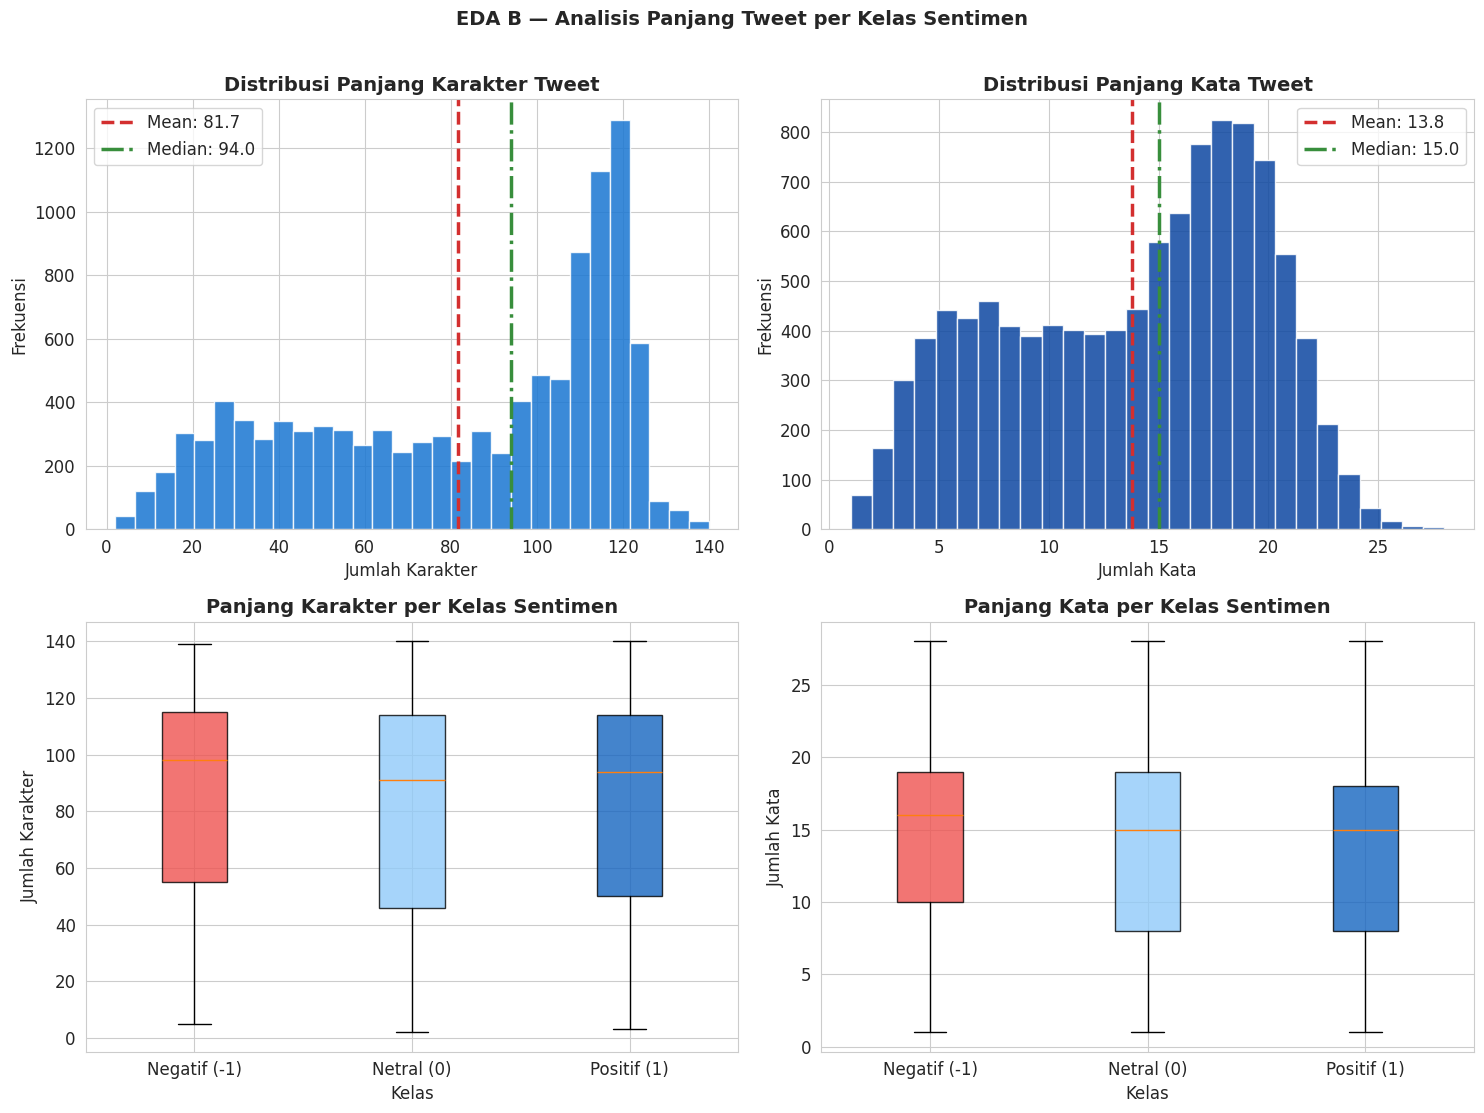


📊 Statistik Panjang Tweet per Kelas:
  Negatif: avg 84.7 kar / 14.4 kata  | max 139 kar
  Netral : avg 79.9 kar / 13.6 kata  | max 140 kar
  Positif: avg 81.9 kar / 13.4 kata  | max 140 kar

💡 Tweet negatif sedikit lebih panjang karena pengguna cenderung
   menjelaskan keluhan lebih detail. Tweet netral cenderung informatif.


In [ ]:
# ============================================================
# EDA B: DISTRIBUSI PANJANG TWEET
# ============================================================

df['char_length'] = df['Tweet'].apply(len)
df['word_length'] = df['Tweet'].apply(lambda x: len(x.split()))

fig, axes = plt.subplots(2, 2, figsize=(15, 11))

# Histogram panjang karakter
axes[0,0].hist(df['char_length'], bins=30, color='#1976D2', edgecolor='white', alpha=0.85)
axes[0,0].axvline(df['char_length'].mean(), color='#D32F2F', linestyle='--',
                  linewidth=2.5, label=f'Mean: {df["char_length"].mean():.1f}')
axes[0,0].axvline(df['char_length'].median(), color='#388E3C', linestyle='-.',
                  linewidth=2.5, label=f'Median: {df["char_length"].median():.1f}')
axes[0,0].set_title('Distribusi Panjang Karakter Tweet')
axes[0,0].set_xlabel('Jumlah Karakter'); axes[0,0].set_ylabel('Frekuensi')
axes[0,0].legend()

# Histogram panjang kata
axes[0,1].hist(df['word_length'], bins=28, color='#0D47A1', edgecolor='white', alpha=0.85)
axes[0,1].axvline(df['word_length'].mean(), color='#D32F2F', linestyle='--',
                  linewidth=2.5, label=f'Mean: {df["word_length"].mean():.1f}')
axes[0,1].axvline(df['word_length'].median(), color='#388E3C', linestyle='-.',
                  linewidth=2.5, label=f'Median: {df["word_length"].median():.1f}')
axes[0,1].set_title('Distribusi Panjang Kata Tweet')
axes[0,1].set_xlabel('Jumlah Kata'); axes[0,1].set_ylabel('Frekuensi')
axes[0,1].legend()

# Boxplot per kelas
bp_colors = ['#EF5350', '#90CAF9', '#1565C0']
lbl_order = [-1, 0, 1]; lbl_str = ['Negatif (-1)', 'Netral (0)', 'Positif (1)']

bp1 = axes[1,0].boxplot([df[df['sentimen']==s]['char_length'].values for s in lbl_order],
                         patch_artist=True, labels=lbl_str)
for patch, c in zip(bp1['boxes'], bp_colors): patch.set_facecolor(c); patch.set_alpha(0.8)
axes[1,0].set_title('Panjang Karakter per Kelas Sentimen')
axes[1,0].set_xlabel('Kelas'); axes[1,0].set_ylabel('Jumlah Karakter')

bp2 = axes[1,1].boxplot([df[df['sentimen']==s]['word_length'].values for s in lbl_order],
                         patch_artist=True, labels=lbl_str)
for patch, c in zip(bp2['boxes'], bp_colors): patch.set_facecolor(c); patch.set_alpha(0.8)
axes[1,1].set_title('Panjang Kata per Kelas Sentimen')
axes[1,1].set_xlabel('Kelas'); axes[1,1].set_ylabel('Jumlah Kata')

plt.suptitle('EDA B — Analisis Panjang Tweet per Kelas Sentimen',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_B_panjang_tweet.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n📊 Statistik Panjang Tweet per Kelas:")
for s, lbl in zip([-1,0,1], ['Negatif','Netral ','Positif']):
    sub = df[df['sentimen']==s]
    print(f"  {lbl}: avg {sub['char_length'].mean():.1f} kar / {sub['word_length'].mean():.1f} kata  "
          f"| max {sub['char_length'].max()} kar")
print("\n💡 Tweet negatif sedikit lebih panjang karena pengguna cenderung")
print("   menjelaskan keluhan lebih detail. Tweet netral cenderung informatif.")

📊 EDA C: Bag of Words Keseluruhan Dataset (Sebelum Preprocessing)


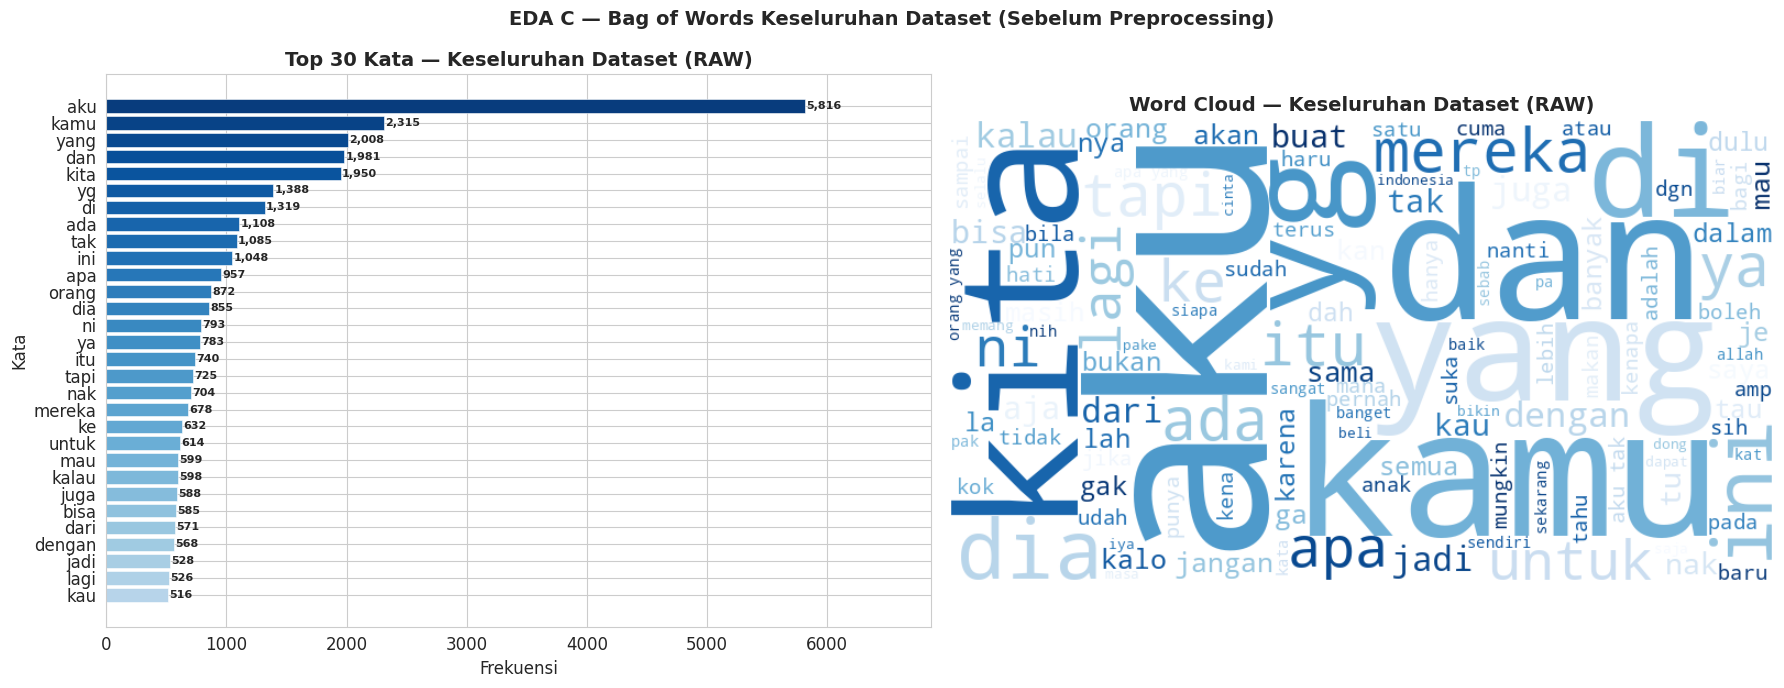


  Total token unik (raw) : 21,786
  Total token (raw)      : 146,036

  Top 10 kata terbanyak di seluruh dataset:
     1. 'aku' → 5,816 kali (3.98%)
     2. 'kamu' → 2,315 kali (1.59%)
     3. 'yang' → 2,008 kali (1.38%)
     4. 'dan' → 1,981 kali (1.36%)
     5. 'kita' → 1,950 kali (1.34%)
     6. 'yg' → 1,388 kali (0.95%)
     7. 'di' → 1,319 kali (0.90%)
     8. 'ada' → 1,108 kali (0.76%)
     9. 'tak' → 1,085 kali (0.74%)
    10. 'ini' → 1,048 kali (0.72%)

💡 Kata 'aku' paling dominan → tweet sangat personal (ekspresi diri).
   Kata-kata stopword banyak mendominasi → preprocessing sangat diperlukan.


In [ ]:
# ============================================================
# EDA C: BAG OF WORDS — KESELURUHAN DATASET (sebelum preprocessing)
# ============================================================
# Ini menunjukkan kata apa yang paling banyak muncul di seluruh dataset
# SEBELUM preprocessing, berguna untuk memahami noise dan kata dominan

print("📊 EDA C: Bag of Words Keseluruhan Dataset (Sebelum Preprocessing)")
print("=" * 65)

# Gabungkan semua tweet, lowercase, tokenisasi sederhana
all_text_raw = ' '.join(df['Tweet'].astype(str).str.lower().tolist())
# Hapus tanda baca dan angka untuk penghitungan sederhana
all_text_raw = re.sub(r'[^a-z\s]', ' ', all_text_raw)
all_words_raw = [w for w in all_text_raw.split() if len(w) > 1]
bow_raw = Counter(all_words_raw)
top30_raw = bow_raw.most_common(30)

words_r, counts_r = zip(*top30_raw)

fig, axes = plt.subplots(1, 2, figsize=(18, 7))

# --- Bar chart Top 30 ---
colors_bow = plt.cm.Blues(np.linspace(0.3, 0.95, 30))
bars_bow = axes[0].barh(list(words_r)[::-1], list(counts_r)[::-1],
                        color=colors_bow, edgecolor='white', linewidth=0.4)
for bar, val in zip(bars_bow, list(counts_r)[::-1]):
    axes[0].text(bar.get_width() + 10, bar.get_y() + bar.get_height()/2,
                 f'{val:,}', va='center', fontsize=8, fontweight='bold')
axes[0].set_title('Top 30 Kata — Keseluruhan Dataset (RAW)', fontweight='bold')
axes[0].set_xlabel('Frekuensi')
axes[0].set_ylabel('Kata')
axes[0].set_xlim(0, max(counts_r) * 1.18)

# --- Word Cloud keseluruhan ---
wc_all = WordCloud(width=750, height=420, background_color='white',
                   colormap='Blues', max_words=120, contour_width=2,
                   contour_color='#1565C0', prefer_horizontal=0.85).generate(
    ' '.join(all_words_raw))
axes[1].imshow(wc_all, interpolation='bilinear')
axes[1].axis('off')
axes[1].set_title('Word Cloud — Keseluruhan Dataset (RAW)', fontweight='bold')

plt.suptitle('EDA C — Bag of Words Keseluruhan Dataset (Sebelum Preprocessing)',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_C_bow_overall.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"\n  Total token unik (raw) : {len(bow_raw):,}")
print(f"  Total token (raw)      : {sum(bow_raw.values()):,}")
print(f"\n  Top 10 kata terbanyak di seluruh dataset:")
for i, (w, c) in enumerate(top30_raw[:10], 1):
    print(f"    {i:>2}. '{w}' → {c:,} kali ({c/sum(bow_raw.values())*100:.2f}%)")
print("\n💡 Kata 'aku' paling dominan → tweet sangat personal (ekspresi diri).")
print("   Kata-kata stopword banyak mendominasi → preprocessing sangat diperlukan.")

📊 EDA D: Bag of Words per Kelas (Sebelum Preprocessing)


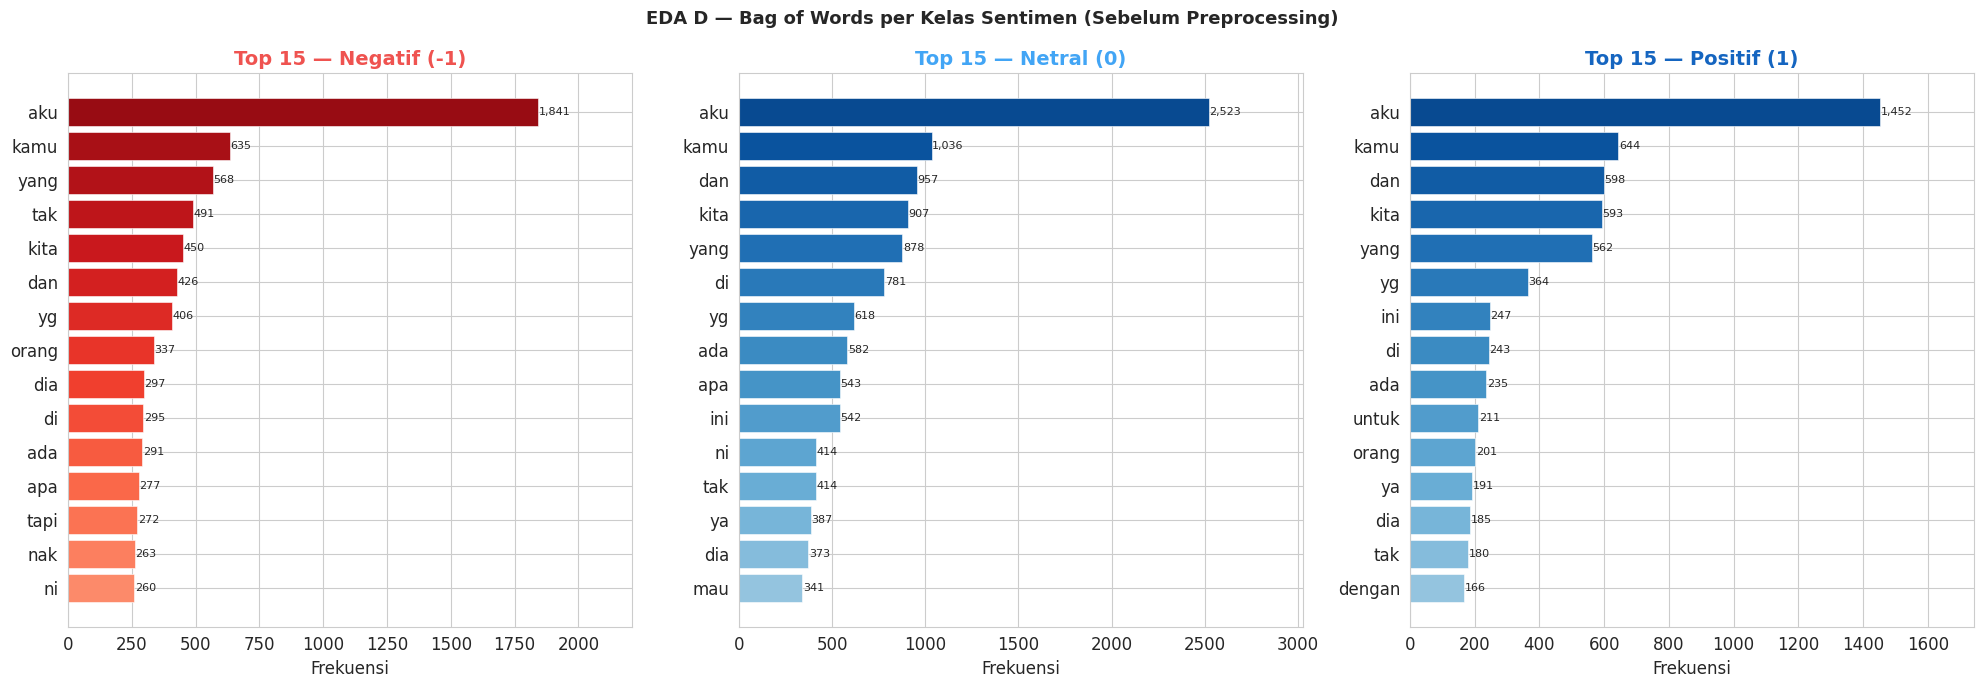


💡 Interpretasi:
   Kata 'aku' mendominasi SEMUA kelas → tweet sangat personal.
   Masih banyak stopword (yang, di, dan, dengan) → perlu preprocessing.
   Setelah preprocessing, kata-kata informatif akan lebih menonjol.


In [ ]:
# ============================================================
# EDA D: BAG OF WORDS PER KELAS SENTIMEN (sebelum preprocessing)
# ============================================================

print("📊 EDA D: Bag of Words per Kelas (Sebelum Preprocessing)")

fig, axes = plt.subplots(1, 3, figsize=(20, 7))
kelas_info = [
    (-1, 'Negatif (-1)', '#EF5350'),
    (0,  'Netral (0)',   '#42A5F5'),
    (1,  'Positif (1)',  '#1565C0')
]

for ax, (val, title, color) in zip(axes, kelas_info):
    text_k = ' '.join(df[df['sentimen']==val]['Tweet'].astype(str).str.lower().tolist())
    text_k = re.sub(r'[^a-z\s]', ' ', text_k)
    words_k = [w for w in text_k.split() if len(w) > 1]
    top15_k = Counter(words_k).most_common(15)
    if top15_k:
        w15, c15 = zip(*top15_k)
        cmap_name = 'Reds' if val==-1 else 'Blues'
        cols = plt.cm.get_cmap(cmap_name)(np.linspace(0.4, 0.9, 15))
        bars_k = ax.barh(list(w15)[::-1], list(c15)[::-1],
                         color=cols, edgecolor='white', linewidth=0.4)
        for bar, v in zip(bars_k, list(c15)[::-1]):
            ax.text(bar.get_width()+2, bar.get_y()+bar.get_height()/2,
                    f'{v:,}', va='center', fontsize=8)
        ax.set_xlim(0, max(c15)*1.2)
    ax.set_title(f'Top 15 — {title}', fontweight='bold', color=color)
    ax.set_xlabel('Frekuensi')

plt.suptitle('EDA D — Bag of Words per Kelas Sentimen (Sebelum Preprocessing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_D_bow_per_kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretasi:")
print("   Kata 'aku' mendominasi SEMUA kelas → tweet sangat personal.")
print("   Masih banyak stopword (yang, di, dan, dengan) → perlu preprocessing.")
print("   Setelah preprocessing, kata-kata informatif akan lebih menonjol.")

---
# 🏷️ Bagian 5: Pelabelan Sentimen — 3 Kelas

## Strategi Pelabelan

Dataset sudah memiliki label numerik yang tinggal dikonversi ke string:

| Label Asli | Nilai | Label Baru | Alasan |
|-----------|-------|-----------|--------|
| `-1` | Negatif | `'negatif'` | Label jelas mencerminkan sentimen negatif |
| `0` | Netral | `'netral'` | **Dipertahankan** — memberikan representasi sentimen yang lebih lengkap |
| `+1` | Positif | `'positif'` | Label jelas mencerminkan sentimen positif |

### Mengapa 3 Kelas?
Klasifikasi tiga kelas memberikan gambaran yang lebih realistis. Dalam praktik nyata (monitoring brand, analisis opini publik, riset sosial), penting untuk membedakan:
- Tweet yang **jelas negatif** (keluhan, kekecewaan)
- Tweet yang **netral** (informasi, berita, deskriptif)
- Tweet yang **jelas positif** (apresiasi, kegembiraan)

> **Catatan tantangan:** Multi-class classification lebih sulit dari binary karena kelas netral sering ambigu dan berada di antara dua kelas lainnya. Namun justru inilah yang menjadikannya penelitian yang lebih bermakna.

In [ ]:
# ============================================================
# PELABELAN SENTIMEN 3 KELAS
# ============================================================

print("🏷️  Pelabelan Sentimen 3 Kelas")
print("=" * 60)

df_original = df.copy()  # Simpan salinan asli

# Mapping label numerik ke string
label_map_final = {-1: 'negatif', 0: 'netral', 1: 'positif'}
df['sentiment'] = df['sentimen'].map(label_map_final)

print(f"  Konversi label:  -1 → 'negatif' | 0 → 'netral' | 1 → 'positif'")
print(f"  Total data awal: {len(df):,} tweet")

# Hapus tweet duplikat
n_before_dup = len(df)
df = df.drop_duplicates(subset=['Tweet']).reset_index(drop=True)
n_dup_removed = n_before_dup - len(df)
print(f"  Tweet duplikat dihapus: {n_dup_removed:,}")
print(f"  Data setelah dedup    : {len(df):,} tweet")

# Distribusi final
final_dist = df['sentiment'].value_counts()
order_dist = ['negatif', 'netral', 'positif']

print(f"\n✅ Distribusi Label Final (3 Kelas):")
print("-" * 45)
for lbl in order_dist:
    count = final_dist.get(lbl, 0)
    print(f"   {lbl.capitalize():>8}: {count:>5,} tweet ({count/len(df)*100:.2f}%)")
print(f"   {'Total':>8}: {len(df):>5,} tweet (100.00%)")

# Cek keseimbangan
ratio = final_dist.max() / final_dist.min()
print(f"\n  Rasio kelas max/min : {ratio:.3f}:1")
print("  ⚠️  Netral jauh lebih banyak — model perlu mempertimbangkan")
print("      bobot kelas agar tidak bias ke kelas mayoritas.")

🏷️  Pelabelan Sentimen 3 Kelas
  Konversi label:  -1 → 'negatif' | 0 → 'netral' | 1 → 'positif'
  Total data awal: 10,806 tweet
  Tweet duplikat dihapus: 705
  Data setelah dedup    : 10,101 tweet

✅ Distribusi Label Final (3 Kelas):
---------------------------------------------
    Negatif: 2,649 tweet (26.23%)
     Netral: 5,019 tweet (49.69%)
    Positif: 2,433 tweet (24.09%)
      Total: 10,101 tweet (100.00%)

  Rasio kelas max/min : 2.063:1
  ⚠️  Netral jauh lebih banyak — model perlu mempertimbangkan
      bobot kelas agar tidak bias ke kelas mayoritas.


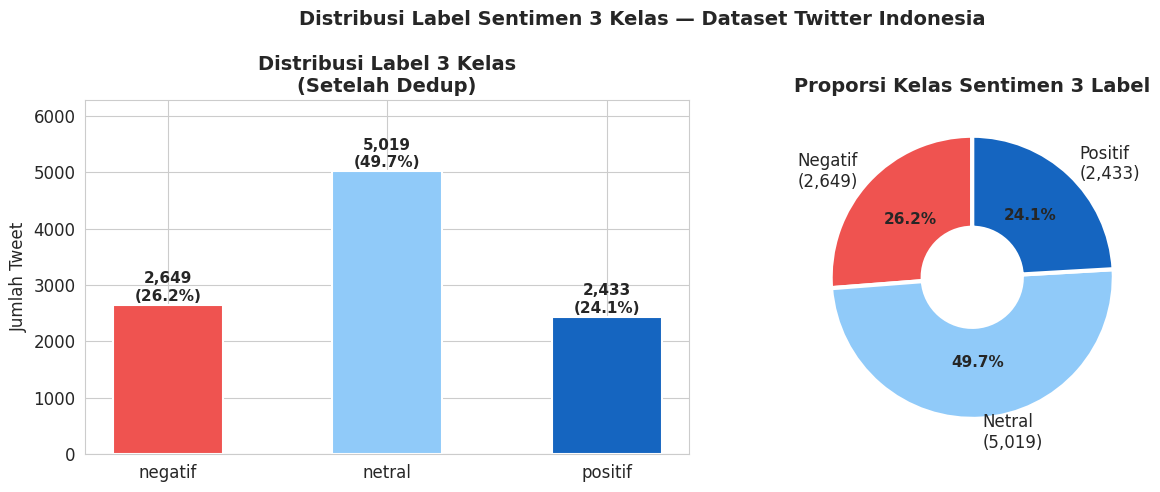

In [ ]:
# Visualisasi distribusi 3 kelas
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
colors3 = {'negatif': '#EF5350', 'netral': '#90CAF9', 'positif': '#1565C0'}
cnts = df['sentiment'].value_counts()[order_dist]

bars = axes[0].bar(cnts.index, cnts.values,
                   color=[colors3[s] for s in cnts.index],
                   edgecolor='white', linewidth=1.5, width=0.5)
for bar, val in zip(bars, cnts.values):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+20,
                 f'{val:,}\n({val/len(df)*100:.1f}%)',
                 ha='center', va='bottom', fontweight='bold', fontsize=11)
axes[0].set_title('Distribusi Label 3 Kelas\n(Setelah Dedup)', fontweight='bold')
axes[0].set_ylabel('Jumlah Tweet')
axes[0].set_ylim(0, max(cnts.values)*1.25)

wedges, texts, autotexts = axes[1].pie(
    cnts.values,
    labels=[f'{s.capitalize()}\n({v:,})' for s,v in zip(cnts.index, cnts.values)],
    autopct='%1.1f%%', colors=[colors3[s] for s in cnts.index],
    startangle=90, wedgeprops={'edgecolor':'white','linewidth':3,'width':0.65})
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(11)
axes[1].set_title('Proporsi Kelas Sentimen 3 Label', fontweight='bold')

plt.suptitle('Distribusi Label Sentimen 3 Kelas — Dataset Twitter Indonesia',
             fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_G_distribusi_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🧹 Bagian 6: Preprocessing

## Solusi Masalah Kata **"tidak"** dan **"iya"** yang Mendominasi

Pada percobaan sebelumnya, ditemukan bahwa:
- Kata **"tidak"** mendominasi SEMUA kelas, bahkan kelas POSITIF
- Kata **"iya"** juga muncul dominan di semua kelas

### Penyebab:
1. `'tak'` (Bahasa Melayu → artinya "tidak") dinormalisasi → `'tidak'` lewat kamus slang
2. `'ya'` dinormalisasi → `'iya'` lewat kamus slang
3. Kata `'tidak'` sendiri memang sangat umum di semua jenis kalimat

### Solusi yang Diterapkan:

| Masalah | Solusi |
|---------|--------|
| `tak` → `tidak` membuat 'tidak' meledak | **Hapus** entri `tak→tidak` dari kamus slang. Biarkan `tak` tetap `tak` (lebih diskriminatif!) |
| `ya` → `iya` membuat 'iya' meledak | **Hapus** entri `ya→iya` dari kamus slang. Buang `ya` sebagai stopword biasa |
| `tidak` dominan di semua kelas | **Tetap pertahankan** `tidak` karena secara linguistik memang penting, tapi **tidak normalisasi `tak`→`tidak`** agar kontribusinya lebih terkontrol |
| `iya` tidak informatif | Hapus dari daftar kata yang dipertahankan (biarkan jadi stopword) |

### Prinsip: Kata Negasi Tetap Dipertahankan, Tapi Tidak Dimanipulasi Berlebihan
```
DIPERTAHANKAN (tidak dihapus sebagai stopword):
    'tidak', 'bukan', 'ga', 'gak', 'ngga', 'nggak', 'jangan', 'belum', 'tanpa'

DIHAPUS dari kamus slang (biarkan tetap seperti aslinya):
    tak, nak, dah, ya, lah, loh, sih, deh, dong
    → ini kata Melayu/partikel yang TIDAK perlu dinormalisasi ke Indonesia
```

In [ ]:
# ============================================================
# SETUP TOOLS PREPROCESSING
# ============================================================

print("⚙️  Menyiapkan tools preprocessing...")

# 1. Stemmer Sastrawi
factory = StemmerFactory()
stemmer = factory.create_stemmer()
print("   ✅ Stemmer Sastrawi siap")

# 2. Stopwords Bahasa Indonesia (NLTK)
stop_words_id = set(stopwords.words('indonesian'))

# Kata negasi WAJIB dipertahankan — hapus dari stopword list
# CATATAN: 'iya' dan 'ya' TIDAK dimasukkan sebagai kata yang dipertahankan
# karena terlalu umum dan tidak cukup diskriminatif
NEGATION_WORDS = {
    'tidak', 'bukan', 'ga', 'gak', 'ngga',
    'nggak', 'jangan', 'belum', 'tanpa'
    # SENGAJA dihapus: 'tak' (biarkan ikut stopword atau tetap bentuk aslinya)
    # SENGAJA dihapus: 'iya', 'ya' (terlalu noise)
}
stop_words_id = stop_words_id - NEGATION_WORDS
print(f"   ✅ Stopwords siap ({len(stop_words_id)} kata)")
print(f"   📌 Negasi DIPERTAHANKAN : {sorted(NEGATION_WORDS)}")
print(f"   📌 'iya','ya','tak' TIDAK dipertahankan — terlalu noise/umum")

# 3. Kamus Normalisasi Slang
# ⚠️ PERBAIKAN KRITIS:
# - HAPUS: 'tak' → 'tidak'  (menyebabkan 'tidak' meledak)
# - HAPUS: 'ya'  → 'iya'    (menyebabkan 'iya' meledak)
# - HAPUS: 'nak', 'dah', 'lah', 'loh', 'sih', 'deh', 'dong'
#   karena partikel Melayu ini tidak perlu dinormalisasi ke Indonesia
SLANG_DICT = {
    # --- Kata ganti ---
    'gue':'saya','gw':'saya','gua':'saya','aku':'saya',
    'sy':'saya','aq':'saya',
    'lo':'kamu','lu':'kamu','loe':'kamu','elo':'kamu',
    'km':'kamu','kmu':'kamu',
    'dy':'dia','doi':'dia','dya':'dia',
    'mrk':'mereka',
    # --- Konjungsi dan partikel Indonesia ---
    'yg':'yang','dgn':'dengan','dg':'dengan',
    'tp':'tapi','tpi':'tapi',
    'krn':'karena','karna':'karena','kalo':'kalau',
    'klu':'kalau','kl':'kalau',
    'utk':'untuk','utuk':'untuk','tuk':'untuk',
    'jg':'juga','jga':'juga',
    'aja':'saja','aj':'saja',
    'sm':'sama','ama':'sama',
    # --- Waktu ---
    'skrg':'sekarang','skg':'sekarang','skrang':'sekarang',
    'ntar':'nanti','tar':'nanti','nnti':'nanti',
    'kmrn':'kemarin',
    # --- Kata kerja & kondisi ---
    'mo':'mau',
    'bs':'bisa','bsa':'bisa',
    'hrs':'harus','hrus':'harus',
    'sdh':'sudah','udh':'sudah','udah':'sudah',
    'blm':'belum','blum':'belum',
    'lg':'lagi','lgi':'lagi',
    'dpt':'dapat','dapet':'dapat',
    'msh':'masih','masi':'masih',
    'pke':'pakai','pake':'pakai',
    'emg':'memang','emang':'memang',
    # --- Kata sifat & emosi ---
    'bgt':'banget','bangt':'banget','bgtt':'banget',
    'bgs':'bagus',
    'keren':'bagus','kerenn':'bagus','kren':'bagus',
    'mantap':'bagus','mantep':'bagus',
    'jos':'bagus','joss':'bagus',
    'jelek':'buruk',
    'parah':'buruk',
    'ancur':'buruk','hancur':'buruk',
    'kzl':'kesal','kesel':'kesal',
    'seneng':'senang','senengg':'senang',
    'happy':'senang','bahagia':'senang',
    'sad':'sedih',
    'susah':'sulit',
    'capek':'lelah','cape':'lelah',
    'cepet':'cepat',
    'lelet':'lambat','lemot':'lambat',
    # --- Ekspresi noise (dihapus dari output) ---
    'wkwk':'','wkwkwk':'','haha':'','hahaha':'',
    'huhu':'','huhuh':'','wkwkwkwk':'',
    # --- Terima kasih ---
    'makasih':'terima kasih','makasi':'terima kasih',
    'mksh':'terima kasih','thx':'terima kasih',
    'thanks':'terima kasih','tq':'terima kasih',
    # --- Ekspresi umum Indonesia ---
    'nih':'ini',
    'tuh':'itu',
    'kyk':'seperti','kayak':'seperti','kyak':'seperti',
    'ngerasa':'merasa','kerasa':'terasa',
    'pengen':'ingin','pengin':'ingin','pgn':'ingin',
    'gitu':'begitu','gini':'begini',
    'knp':'kenapa',
    'ok':'oke','okey':'oke',
    'anj':'anjing','anjir':'anjing',
    # ⚠️ TIDAK ada lagi: 'tak'→'tidak', 'ya'→'iya', 'nak'→'mau',
    # 'dah'→'sudah', 'lah'→'', 'loh'→'', 'sih'→'', 'deh'→'', 'dong'→''
    # Partikel Melayu ini DIBIARKAN apa adanya agar lebih diskriminatif antar kelas
}

print(f"   ✅ Kamus slang siap ({len(SLANG_DICT)} entri)")
print("\n🔑 PERUBAHAN UTAMA dari versi sebelumnya:")
print("   ❌ Dihapus: tak→tidak  (mencegah 'tidak' meledak dari kata Melayu)")
print("   ❌ Dihapus: ya→iya     (mencegah 'iya' meledak dan jadi noise)")
print("   ❌ Dihapus: nak, dah, lah, loh, sih, deh, dong")
print("     (partikel Melayu tetap apa adanya — lebih diskriminatif)")
print("\n✅ Semua tools preprocessing berhasil disiapkan!")

⚙️  Menyiapkan tools preprocessing...
   ✅ Stemmer Sastrawi siap
   ✅ Stopwords siap (752 kata)
   📌 Negasi DIPERTAHANKAN : ['belum', 'bukan', 'ga', 'gak', 'jangan', 'ngga', 'nggak', 'tanpa', 'tidak']
   📌 'iya','ya','tak' TIDAK dipertahankan — terlalu noise/umum
   ✅ Kamus slang siap (120 entri)

🔑 PERUBAHAN UTAMA dari versi sebelumnya:
   ❌ Dihapus: tak→tidak  (mencegah 'tidak' meledak dari kata Melayu)
   ❌ Dihapus: ya→iya     (mencegah 'iya' meledak dan jadi noise)
   ❌ Dihapus: nak, dah, lah, loh, sih, deh, dong
     (partikel Melayu tetap apa adanya — lebih diskriminatif)

✅ Semua tools preprocessing berhasil disiapkan!


In [ ]:
# ============================================================
# FUNGSI PREPROCESSING (MODULAR)
# ============================================================

def remove_emoji(text):
    """Hapus emoji dan karakter unicode khusus."""
    emoji_pattern = re.compile(
        "[" u"\U0001F600-\U0001F64F" u"\U0001F300-\U0001F5FF"
        u"\U0001F680-\U0001F6FF" u"\U0001F1E0-\U0001F1FF"
        u"\U00002702-\U000027B0" u"\U000024C2-\U0001F251" "]+",
        flags=re.UNICODE)
    return emoji_pattern.sub('', text)


def remove_twitter_artifacts(text):
    """Hapus elemen khusus Twitter: URL, mention, simbol hashtag, RT."""
    text = re.sub(r'http\S+|https\S+|www\.\S+', '', text)  # URL
    text = re.sub(r'@\w+', '', text)                        # Mention
    text = re.sub(r'#(\w+)', r'\1', text)                   # Simbol hashtag
    text = re.sub(r'\bRT\b', '', text)                      # Retweet marker
    return text


def normalize_slang(text, slang_dict):
    """Ganti kata slang dengan kata baku dari kamus."""
    words = text.split()
    normalized = [slang_dict.get(word, word) for word in words]
    return ' '.join(w for w in normalized if w.strip() != '')


def remove_stopwords_keep_negation(tokens, stop_words, negation_words):
    """
    Hapus stopword KECUALI kata negasi.
    Contoh: 'senang' ≠ 'tidak senang' — makna berlawanan!
    """
    return [w for w in tokens if w not in stop_words or w in negation_words]


def stem_tokens(tokens, stemmer):
    """Stemming Bahasa Indonesia dengan Sastrawi."""
    return [stemmer.stem(w) for w in tokens]


def preprocess_tweet(text,
                     slang_dict=SLANG_DICT,
                     stop_words=stop_words_id,
                     negation_words=NEGATION_WORDS,
                     stemmer=stemmer):
    """
    Pipeline preprocessing lengkap untuk tweet Bahasa Indonesia.
    Langkah: lowercase → de-emoji → Twitter artifacts → angka →
             punctuation → slang normalization → whitespace →
             tokenize → filter pendek → stopword (±negasi) → stem
    """
    if not isinstance(text, str) or not text.strip():
        return ''
    text = text.lower()                                        # 1. Lowercase
    text = remove_emoji(text)                                  # 2. Emoji
    text = remove_twitter_artifacts(text)                      # 3. Twitter
    text = re.sub(r'\d+', '', text)                            # 4. Angka
    text = text.translate(str.maketrans('','',string.punctuation))  # 5. Punct
    text = normalize_slang(text, slang_dict)                   # 6. Slang
    text = re.sub(r'\s+', ' ', text).strip()                   # 7. Whitespace
    tokens = word_tokenize(text)                               # 8. Tokenize
    tokens = [t for t in tokens if len(t) > 1]                # 9. Filter < 2 char
    tokens = remove_stopwords_keep_negation(tokens, stop_words, negation_words)  # 10
    tokens = stem_tokens(tokens, stemmer)                      # 11. Stem
    return ' '.join(tokens)


print("✅ Fungsi preprocessing berhasil didefinisikan!")
print("   Pipeline: lowercase → de-emoji → Twitter noise → angka →")
print("            punctuation → slang → whitespace → tokenize →")
print("            filter → stopword(±negasi) → stem")

✅ Fungsi preprocessing berhasil didefinisikan!
   Pipeline: lowercase → de-emoji → Twitter noise → angka →
            punctuation → slang → whitespace → tokenize →
            filter → stopword(±negasi) → stem


In [ ]:
# ============================================================
# DEMONSTRASI PREPROCESSING — SEBELUM vs SESUDAH
# ============================================================

print("🔍 Demonstrasi Preprocessing (Sebelum vs Sesudah)")
print("=" * 75)

demo_tweets = [
    ("lagu bosan apa yang aku save ni huhuhuhuhuhu",                      "NEGATIF"),
    ("aku tak faham betul jenis orang yang tak reti nak sangkut balik",   "NEGATIF"),
    ("makasih loh ntar kita bagi hasil aku 99 sisanya buat kamu",         "POSITIF"),
    ("ya aku akan menjadi satu satunya bukan nomor satu",                 "POSITIF"),
    ("barusan liat tulisan di belakang truk rela injek kopling demi kamu","NETRAL" ),
]

for i, (tweet, label) in enumerate(demo_tweets, 1):
    cleaned = preprocess_tweet(tweet)
    print(f"\nContoh {i} [{label}]:")
    print(f"  SEBELUM : {tweet}")
    print(f"  SESUDAH : {cleaned}")
    print(f"  Kata: {len(tweet.split()):>3} → {len(cleaned.split()):>3}")
    print("-" * 75)

print("\n💡 Perhatikan:")
print("   'tak' (Melayu) TIDAK lagi dinormalisasi ke 'tidak'")
print("   → 'tidak' tidak lagi meledak dari kontribusi kata Melayu")
print("   'ya' TIDAK lagi dinormalisasi ke 'iya'")
print("   → 'iya' tidak lagi mendominasi chart secara tidak natural")

🔍 Demonstrasi Preprocessing (Sebelum vs Sesudah)

Contoh 1 [NEGATIF]:
  SEBELUM : lagu bosan apa yang aku save ni huhuhuhuhuhu
  SESUDAH : lagu bosan save ni huhuhuhuhuhu
  Kata:   8 →   5
---------------------------------------------------------------------------

Contoh 2 [NEGATIF]:
  SEBELUM : aku tak faham betul jenis orang yang tak reti nak sangkut balik
  SESUDAH : faham jenis orang ret nak sangkut
  Kata:  12 →   6
---------------------------------------------------------------------------

Contoh 3 [POSITIF]:
  SEBELUM : makasih loh ntar kita bagi hasil aku 99 sisanya buat kamu
  SESUDAH : terima kasih loh hasil sisa
  Kata:  11 →   5
---------------------------------------------------------------------------

Contoh 4 [POSITIF]:
  SEBELUM : ya aku akan menjadi satu satunya bukan nomor satu
  SESUDAH : ya satu bukan nomor
  Kata:   9 →   4
---------------------------------------------------------------------------

Contoh 5 [NETRAL]:
  SEBELUM : barusan liat tulisan di belakang

In [ ]:
# ============================================================
# TERAPKAN PREPROCESSING KE SELURUH DATASET
# ============================================================

print(f"⏳ Menerapkan preprocessing ke {len(df):,} tweet...")
print("   (Mungkin 2-5 menit karena Sastrawi stemming)")
print("-" * 60)

start = time.time()
df['tweet_clean'] = df['Tweet'].apply(preprocess_tweet)
elapsed = time.time() - start

# Hapus tweet kosong setelah preprocessing
before = len(df)
df = df[df['tweet_clean'].str.strip() != ''].reset_index(drop=True)
after = len(df)

print(f"\n✅ Preprocessing selesai dalam {elapsed:.1f} detik!")
print(f"   Data sebelum : {before:,}")
print(f"   Data sesudah : {after:,}")
print(f"   Dihapus      : {before-after} tweet (konten kosong setelah preprocessing)")

print("\n📋 Perbandingan 5 sampel (Original vs Cleaned):")
print("-" * 75)
for idx, row in df[['Tweet','sentiment','tweet_clean']].head(5).iterrows():
    print(f"\n[{idx+1}] [{row['sentiment'].upper()}]")
    print(f"  ORIGINAL : {str(row['Tweet'])[:120]}")
    print(f"  CLEANED  : {str(row['tweet_clean'])[:120]}")

⏳ Menerapkan preprocessing ke 10,101 tweet...
   (Mungkin 2-5 menit karena Sastrawi stemming)
------------------------------------------------------------

✅ Preprocessing selesai dalam 5.8 detik!
   Data sebelum : 10,101
   Data sesudah : 10,020
   Dihapus      : 81 tweet (konten kosong setelah preprocessing)

📋 Perbandingan 5 sampel (Original vs Cleaned):
---------------------------------------------------------------------------

[1] [NEGATIF]
  ORIGINAL : lagu bosan apa yang aku save ni huhuhuhuhuhuhuhuhuhuuuuuuuuuuuuuu
  CLEANED  : lagu bosan save ni huhuhuhuhuhuhuhuhuhuuuuuuuuuuuuuu

[2] [NEGATIF]
  ORIGINAL : kita lanjutkan saja diam ini hingga kau dan aku mengerti tidak semua kebersamaan harus melibatkan hati 
  CLEANED  : lanjut diam kau erti tidak sama libat hati

[3] [POSITIF]
  ORIGINAL : doa rezeki tak putus inna haa zaa larizquna maa lahu min na fadesungguhnya ini ialah pemberian kami kepada kamu p 
  CLEANED  : doa rezeki putus inna haa zaa larizquna maa lahu min na fade

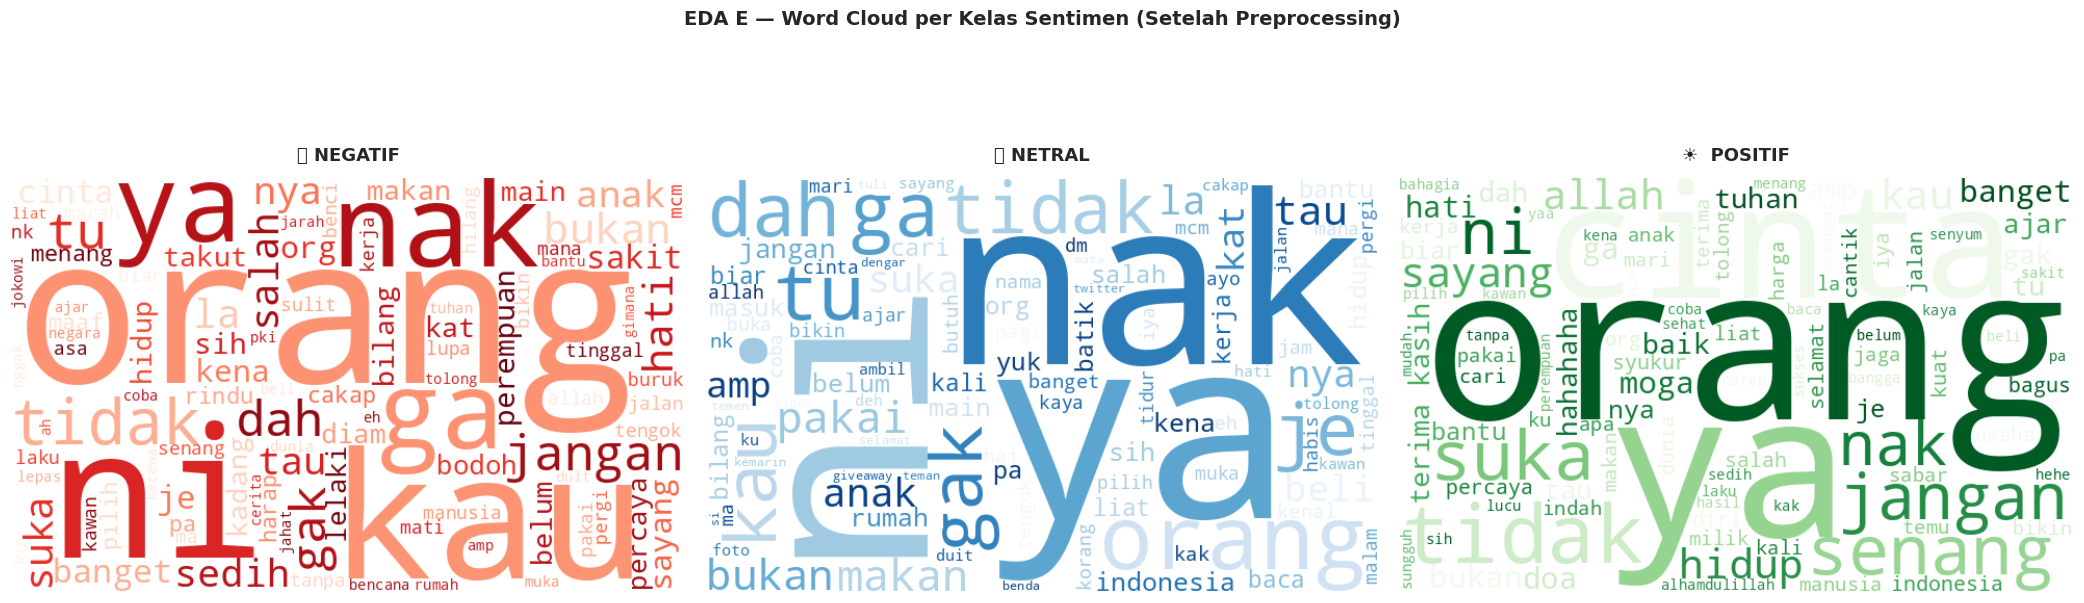


💡 Interpretasi Word Cloud (Setelah Perbaikan Preprocessing):
-----------------------------------------------------------------
  NEGATIF  : Kata seperti 'sedih','bosan','lelah','takut' lebih menonjol
             tanpa 'tidak' mendominasi secara tidak proporsional
  NETRAL   : Kata-kata informatif/deskriptif mendominasi
  POSITIF  : Kata-kata apresiasi dan kegembiraan lebih terlihat
             'tidak' jika muncul lebih sedikit karena 'tak' sudah
             tidak dinormalisasi ke 'tidak' lagi


In [ ]:
# ============================================================
# EDA E: WORD CLOUD — 3 KELAS (Setelah Preprocessing)
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
wc_configs = [
    ('negatif', '🌧️ NEGATIF',  'Reds',   '#D32F2F'),
    ('netral',  '⛅ NETRAL',   'Blues',  '#1565C0'),
    ('positif', '☀️  POSITIF', 'Greens', '#2E7D32'),
]

for ax, (lbl, title, cmap, contour) in zip(axes, wc_configs):
    text_lbl = ' '.join(df[df['sentiment']==lbl]['tweet_clean'].tolist())
    if text_lbl.strip():
        wc = WordCloud(width=650, height=400, background_color='white',
                       colormap=cmap, max_words=100, contour_width=2,
                       contour_color=contour, prefer_horizontal=0.85,
                       min_font_size=8).generate(text_lbl)
        ax.imshow(wc, interpolation='bilinear')
    ax.set_title(title, fontweight='bold', fontsize=13, pad=12)
    ax.axis('off')

plt.suptitle('EDA E — Word Cloud per Kelas Sentimen (Setelah Preprocessing)',
             fontsize=14, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('eda_E_wordcloud_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretasi Word Cloud (Setelah Perbaikan Preprocessing):")
print("-" * 65)
print("  NEGATIF  : Kata seperti 'sedih','bosan','lelah','takut' lebih menonjol")
print("             tanpa 'tidak' mendominasi secara tidak proporsional")
print("  NETRAL   : Kata-kata informatif/deskriptif mendominasi")
print("  POSITIF  : Kata-kata apresiasi dan kegembiraan lebih terlihat")
print("             'tidak' jika muncul lebih sedikit karena 'tak' sudah")
print("             tidak dinormalisasi ke 'tidak' lagi")

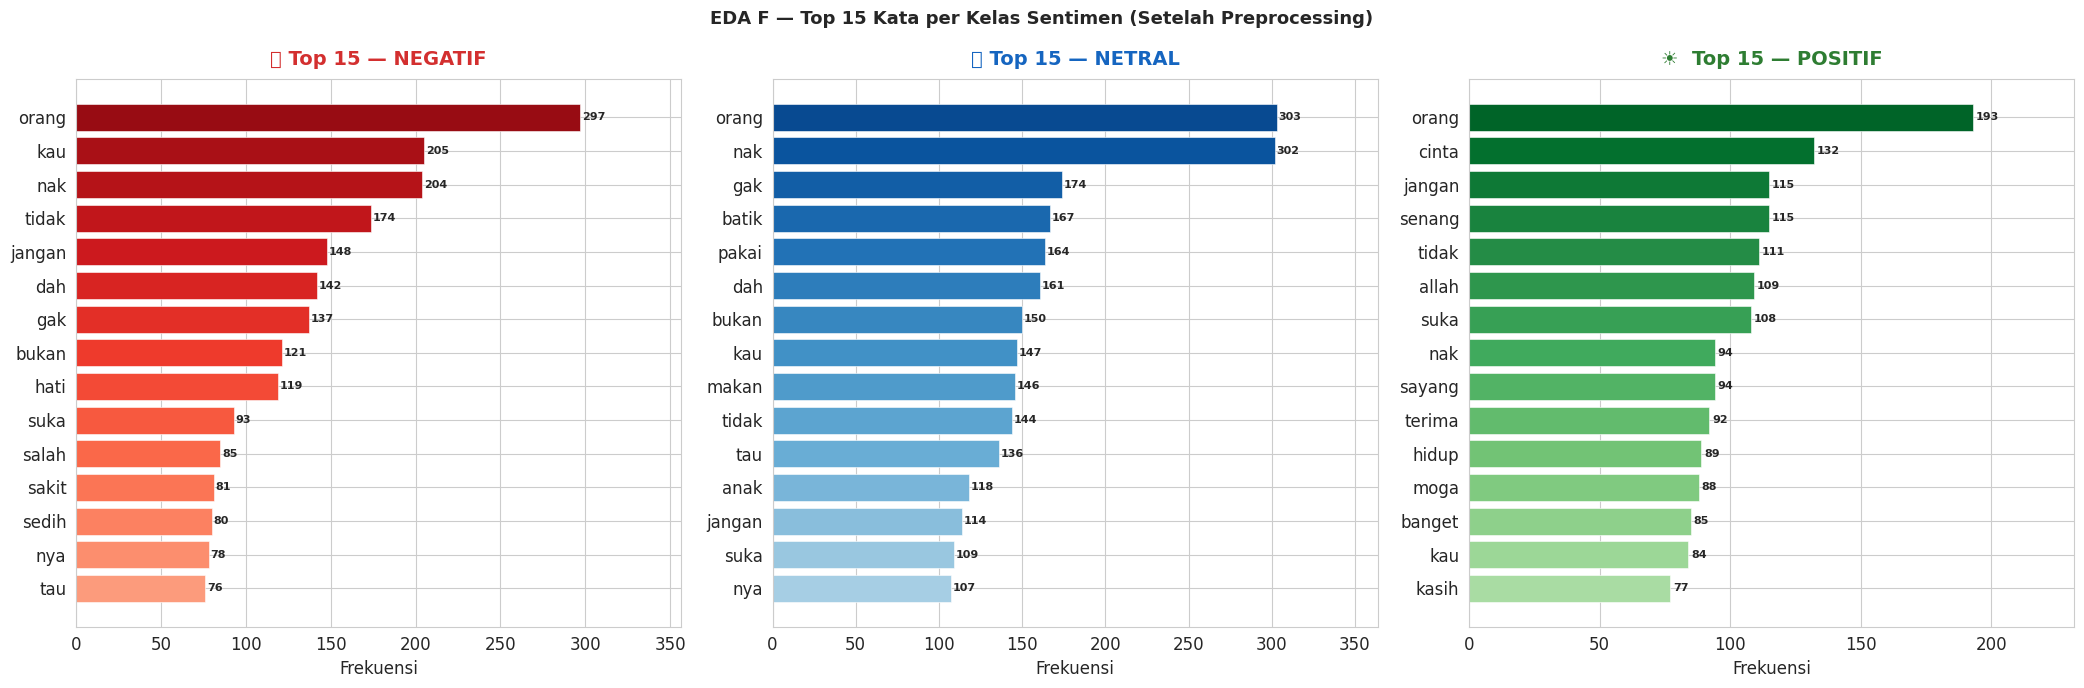


💡 Interpretasi Top Words:
-----------------------------------------------------------------
  Setelah perbaikan preprocessing, distribusi kata jauh lebih
  representatif untuk masing-masing kelas sentimen.
  Kata 'saya' masih dominan (personal expression), namun
  kata-kata emosional kini lebih terlihat di chart.


In [ ]:
# ============================================================
# EDA F: TOP FREQUENT WORDS — 3 KELAS (Setelah Preprocessing)
# ============================================================

def get_top_words(series, n=15):
    all_words = ' '.join(series.dropna()).split()
    return Counter([w for w in all_words if len(w) > 2]).most_common(n)

top_neg = get_top_words(df[df['sentiment']=='negatif']['tweet_clean'])
top_net = get_top_words(df[df['sentiment']=='netral']['tweet_clean'])
top_pos = get_top_words(df[df['sentiment']=='positif']['tweet_clean'])

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
top_configs = [
    (top_neg, '🌧️ Top 15 — NEGATIF', 'Reds',   '#D32F2F'),
    (top_net, '⛅ Top 15 — NETRAL',  'Blues',  '#1565C0'),
    (top_pos, '☀️  Top 15 — POSITIF','Greens', '#2E7D32'),
]

for ax, (top_data, title, cmap, title_color) in zip(axes, top_configs):
    if top_data:
        ws, cs = zip(*top_data)
        cols = plt.cm.get_cmap(cmap)(np.linspace(0.35, 0.9, len(ws)))
        bars_t = ax.barh(list(ws)[::-1], list(cs)[::-1],
                         color=cols, edgecolor='white', linewidth=0.4)
        for bar, val in zip(bars_t, list(cs)[::-1]):
            ax.text(bar.get_width()+1, bar.get_y()+bar.get_height()/2,
                    f'{val:,}', va='center', fontsize=8, fontweight='bold')
        ax.set_xlim(0, max(cs)*1.2)
    ax.set_title(title, fontweight='bold', color=title_color, pad=10)
    ax.set_xlabel('Frekuensi')

plt.suptitle('EDA F — Top 15 Kata per Kelas Sentimen (Setelah Preprocessing)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_F_topwords_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Interpretasi Top Words:")
print("-" * 65)
print("  Setelah perbaikan preprocessing, distribusi kata jauh lebih")
print("  representatif untuk masing-masing kelas sentimen.")
print("  Kata 'saya' masih dominan (personal expression), namun")
print("  kata-kata emosional kini lebih terlihat di chart.")

---
# ✂️ Bagian 7: Train-Test Split

Dataset dibagi **80% training / 20% testing** dengan **stratified split** untuk memastikan proporsi ketiga kelas terjaga di kedua subset.

✂️  HASIL TRAIN-TEST SPLIT (3 KELAS)
  Total data   : 10,020 tweet
  Training set :  8,016 tweet (80.0%)
  Testing set  :  2,004  tweet (20.0%)

📊 Distribusi Kelas (Stratified):
-------------------------------------------------------
  Kelas         Train   Train%     Test    Test%
  ----------------------------------------------
  Negatif       2,115    26.4%      529    26.4%
  Netral        3,972    49.6%      993    49.6%
  Positif       1,929    24.1%      482    24.1%

✅ Stratified split berhasil — proporsi ketiga kelas terjaga!


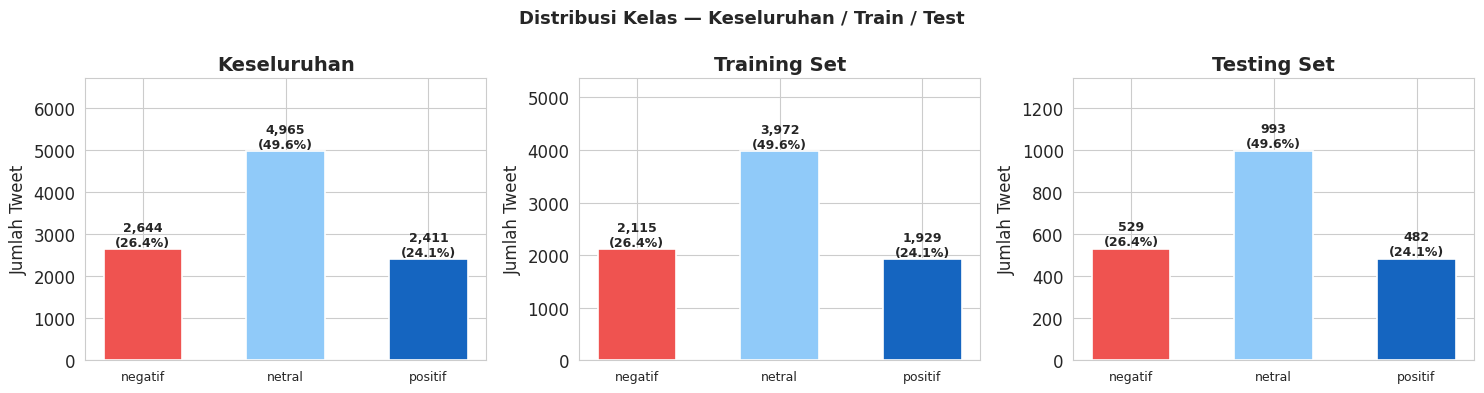

In [ ]:
# ============================================================
# TRAIN-TEST SPLIT (STRATIFIED — 3 KELAS)
# ============================================================

X = df['tweet_clean']
y = df['sentiment']  # 3 kelas: 'negatif', 'netral', 'positif'

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("=" * 60)
print("✂️  HASIL TRAIN-TEST SPLIT (3 KELAS)")
print("=" * 60)
print(f"  Total data   : {len(df):>6,} tweet")
print(f"  Training set : {len(X_train):>6,} tweet ({len(X_train)/len(df)*100:.1f}%)")
print(f"  Testing set  : {len(X_test):>6,}  tweet ({len(X_test)/len(df)*100:.1f}%)")

order_lbl = ['negatif', 'netral', 'positif']

print("\n📊 Distribusi Kelas (Stratified):")
print("-" * 55)
print(f"  {'Kelas':<10} {'Train':>8} {'Train%':>8} {'Test':>8} {'Test%':>8}")
print(f"  {'-'*46}")
for lbl in order_lbl:
    tr = (y_train==lbl).sum(); te = (y_test==lbl).sum()
    print(f"  {lbl.capitalize():<10} {tr:>8,} {tr/len(y_train)*100:>7.1f}% "
          f"{te:>8,} {te/len(y_test)*100:>7.1f}%")

print("\n✅ Stratified split berhasil — proporsi ketiga kelas terjaga!")

# Visualisasi
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
colors3 = ['#EF5350', '#90CAF9', '#1565C0']
datasets_viz = [(y,'Keseluruhan','#1976D2'),(y_train,'Training Set','#0D47A1'),
                (y_test,'Testing Set','#42A5F5')]
for ax, (data, title, _) in zip(axes, datasets_viz):
    cnts = pd.Series(data).value_counts()[order_lbl]
    bars = ax.bar(cnts.index, cnts.values, color=colors3, edgecolor='white', linewidth=1.2, width=0.55)
    for bar, val in zip(bars, cnts.values):
        ax.text(bar.get_x()+bar.get_width()/2., bar.get_height()+5,
                f'{val:,}\n({val/len(data)*100:.1f}%)',
                ha='center', va='bottom', fontsize=9, fontweight='bold')
    ax.set_title(title, fontweight='bold'); ax.set_ylabel('Jumlah Tweet')
    ax.set_ylim(0, max(cnts.values)*1.35)
    ax.tick_params(axis='x', labelsize=9)

plt.suptitle('Distribusi Kelas — Keseluruhan / Train / Test', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('train_test_split_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🔢 Bagian 8: TF-IDF Vectorization (Unigram)

## Konsep TF-IDF

$$\text{TF-IDF}(t,d) = \underbrace{\log(1+f_{t,d})}_{\text{TF sublinear}} \times \underbrace{\log\left(\frac{N}{df_t}\right)}_{\text{IDF}}$$

Kata yang informatif dan diskriminatif antar kelas mendapat skor tinggi. Kata yang muncul di semua kelas (sangat umum) mendapat IDF rendah → skor rendah.

## Konfigurasi untuk Multi-Class:
- `min_df=2` — hapus kata yang hanya muncul di 1 dokumen (terlalu sparse)
- `max_df=0.95` — hapus kata yang muncul di >95% dokumen (terlalu umum)
- `sublinear_tf=True` — kurangi dominasi kata yang sangat sering muncul

In [ ]:
# ============================================================
# TF-IDF VECTORIZATION (UNIGRAM ONLY)
# ============================================================

tfidf_vectorizer = TfidfVectorizer(
    ngram_range=(1, 1),          # UNIGRAM ONLY
    max_features=10000,          # 10.000 fitur terbaik
    min_df=2,                    # Kata harus muncul di ≥2 dokumen
    max_df=0.95,                 # Abaikan kata di >95% dokumen
    sublinear_tf=True,           # log(1+tf) — kurangi bias frekuensi
    analyzer='word',
    token_pattern=r'\b\w{2,}\b'  # Token minimal 2 karakter
)

print("⏳ Melakukan TF-IDF Vectorization...")
X_train_tfidf = tfidf_vectorizer.fit_transform(X_train)  # Fit HANYA pada train
X_test_tfidf  = tfidf_vectorizer.transform(X_test)        # Transform test saja

feature_names = tfidf_vectorizer.get_feature_names_out()
nnz = X_train_tfidf.nnz
total_e = X_train_tfidf.shape[0] * X_train_tfidf.shape[1]

print("\n" + "=" * 60)
print("📊 HASIL TF-IDF VECTORIZATION")
print("=" * 60)
print(f"  Jumlah fitur (vocabulary) : {len(feature_names):>8,}")
print(f"  Dimensi matrix TRAIN      : {X_train_tfidf.shape[0]:>6,} x {X_train_tfidf.shape[1]:,}")
print(f"  Dimensi matrix TEST       : {X_test_tfidf.shape[0]:>6,} x {X_test_tfidf.shape[1]:,}")
print(f"  Sparsity (train)          : {1-nnz/total_e:.4%}")
print(f"  Non-zero elements         : {nnz:,} dari {total_e:,}")
print(f"\n  10 Fitur pertama: {list(feature_names[:10])}")
print("\n✅ Fit hanya pada X_train → tidak ada data leakage!")

⏳ Melakukan TF-IDF Vectorization...

📊 HASIL TF-IDF VECTORIZATION
  Jumlah fitur (vocabulary) :    5,561
  Dimensi matrix TRAIN      :  8,016 x 5,561
  Dimensi matrix TEST       :  2,004 x 5,561
  Sparsity (train)          : 99.8870%
  Non-zero elements         : 50,394 dari 44,576,976

  10 Fitur pertama: ['aa', 'aaaa', 'aaaaa', 'aah', 'aamiin', 'aat', 'ab', 'abadi', 'abah', 'abai']

✅ Fit hanya pada X_train → tidak ada data leakage!


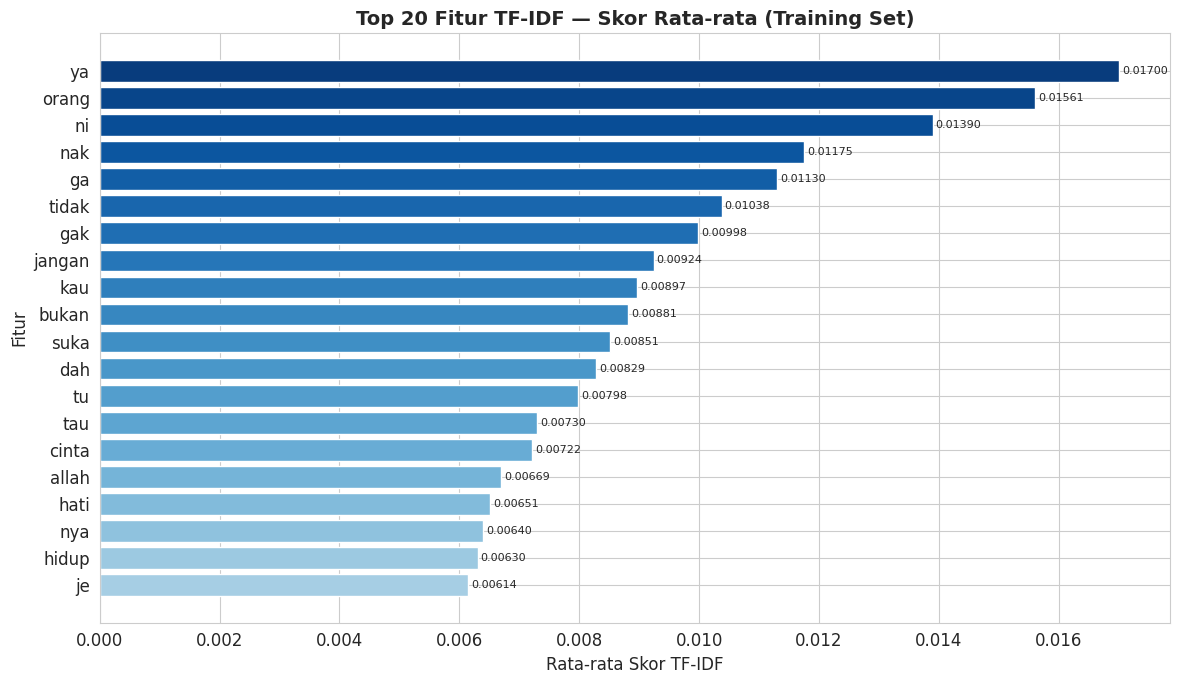


💡 Fitur dengan skor tinggi = kata paling diskriminatif antar kelas.


In [ ]:
# Visualisasi Top TF-IDF features
tfidf_scores = np.array(X_train_tfidf.mean(axis=0)).flatten()
top_idx = tfidf_scores.argsort()[-20:][::-1]
top_feats = [(feature_names[i], tfidf_scores[i]) for i in top_idx]
fw, fs = zip(*top_feats)

fig, ax = plt.subplots(figsize=(12, 7))
colors_f = plt.cm.Blues(np.linspace(0.35, 0.95, len(fw)))
ax.barh(list(fw)[::-1], list(fs)[::-1], color=colors_f, edgecolor='white')
for i, (score, word) in enumerate(zip(list(fs)[::-1], list(fw)[::-1])):
    ax.text(score+0.00005, i, f'{score:.5f}', va='center', fontsize=8)
ax.set_title('Top 20 Fitur TF-IDF — Skor Rata-rata (Training Set)', fontweight='bold')
ax.set_xlabel('Rata-rata Skor TF-IDF'); ax.set_ylabel('Fitur')
plt.tight_layout()
plt.savefig('top_tfidf_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()
print("\n💡 Fitur dengan skor tinggi = kata paling diskriminatif antar kelas.")

---
# 🤖 Bagian 9: Training Model — Linear SVM (Multi-Class)

## LinearSVC untuk Multi-Class Classification

LinearSVC secara otomatis menangani multi-class menggunakan strategi **One-vs-Rest (OvR)**:
- **Negatif vs (Netral + Positif)**
- **Netral vs (Negatif + Positif)**
- **Positif vs (Negatif + Netral)**

Model memilih kelas dengan **confidence tertinggi** dari ketiga binary classifier.

### Penanganan Class Imbalance:
Karena kelas netral (~49%) jauh lebih banyak dari negatif (~27%) dan positif (~24%), kita menggunakan **`class_weight='balanced'`** agar model tidak bias ke kelas mayoritas.

In [ ]:
# ============================================================
# TRAINING MODEL LINEAR SVM — MULTI-CLASS (3 KELAS)
# ============================================================

print("🤖 Training Model LinearSVC (Multi-Class: Negatif/Netral/Positif)...")
print("=" * 65)

svm_model = LinearSVC(
    C=1.0,                    # Regularisasi: C kecil = margin lebih lebar
    max_iter=5000,            # Lebih banyak iterasi untuk multi-class
    random_state=42,
    loss='squared_hinge',     # Fungsi loss stabil
    multi_class='ovr',        # One-vs-Rest: standar untuk multi-class SVM
    class_weight='balanced'   # Kompensasi ketidakseimbangan kelas netral
)

start_time = time.time()
svm_model.fit(X_train_tfidf, y_train)
train_time = time.time() - start_time

y_pred_train = svm_model.predict(X_train_tfidf)
train_acc = accuracy_score(y_train, y_pred_train)

print(f"  ✅ Model berhasil dilatih!")
print(f"  Waktu training          : {train_time:.4f} detik")
print(f"  Dimensi input           : {X_train_tfidf.shape[0]:,} x {X_train_tfidf.shape[1]:,}")
print(f"  Kelas yang dipelajari   : {list(svm_model.classes_)}")
print(f"  Multi-class strategi    : One-vs-Rest (OvR)")
print(f"  Class weight            : balanced (kompensasi imbalance)")
print(f"  Training Accuracy       : {train_acc:.4f} ({train_acc*100:.2f}%)")
print("  (Evaluasi utama pada test set — bukan training set)")

🤖 Training Model LinearSVC (Multi-Class: Negatif/Netral/Positif)...
  ✅ Model berhasil dilatih!
  Waktu training          : 0.0896 detik
  Dimensi input           : 8,016 x 5,561
  Kelas yang dipelajari   : ['negatif', 'netral', 'positif']
  Multi-class strategi    : One-vs-Rest (OvR)
  Class weight            : balanced (kompensasi imbalance)
  Training Accuracy       : 0.9011 (90.11%)
  (Evaluasi utama pada test set — bukan training set)


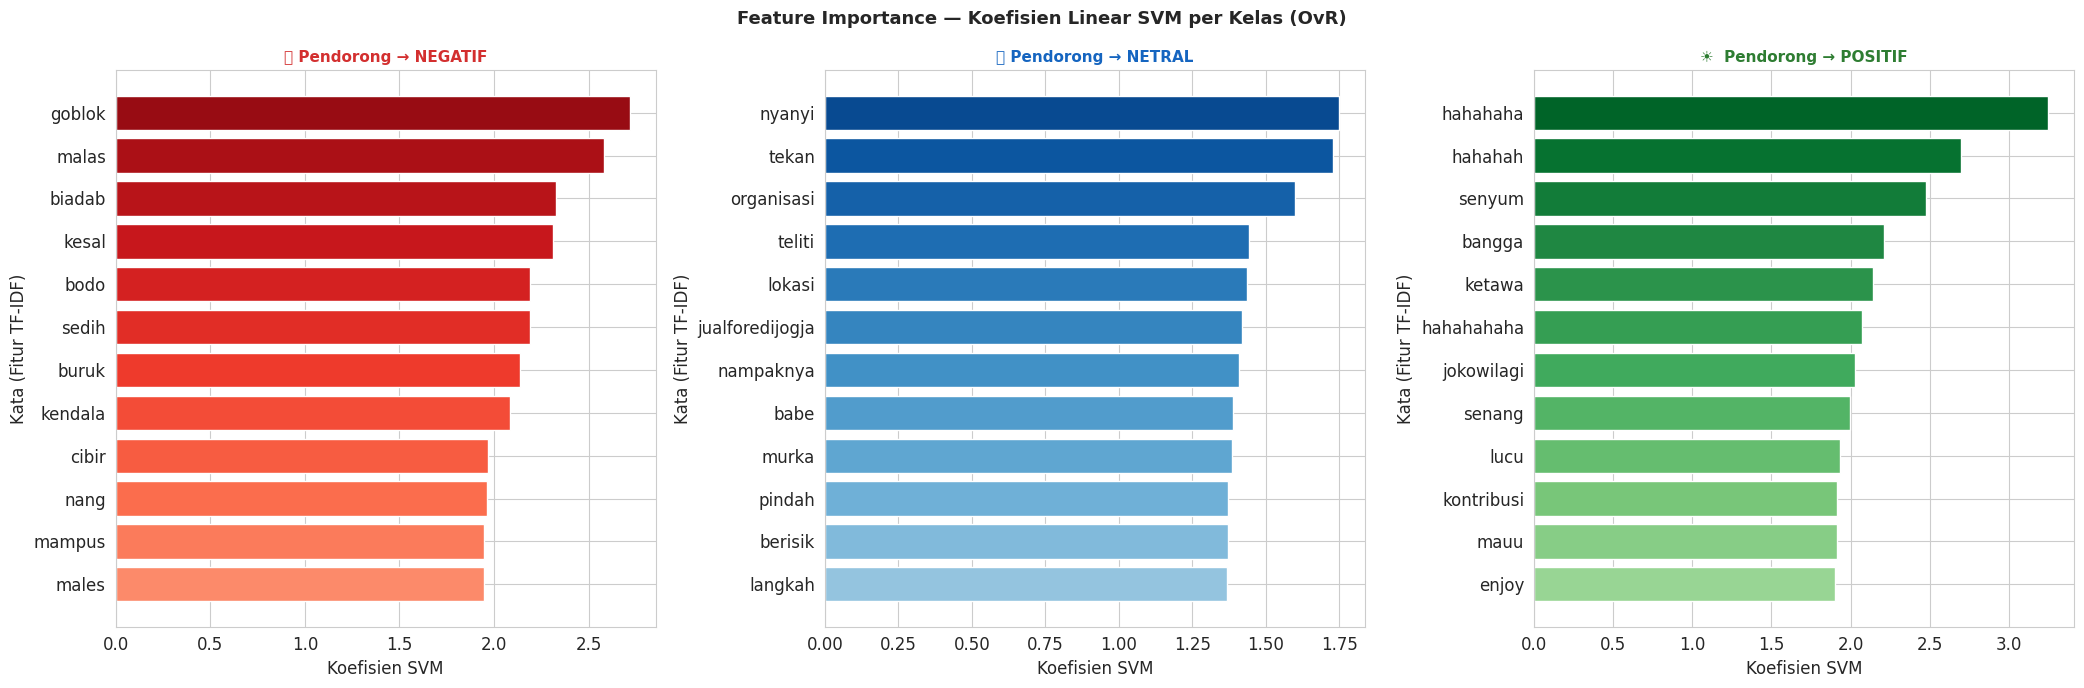


💡 Koefisien positif besar → kata kuat mendorong prediksi ke kelas tersebut.
   Dengan OvR, setiap kelas memiliki set koefisien sendiri.


In [ ]:
# ============================================================
# VISUALISASI KOEFISIEN SVM — PER KELAS
# ============================================================
# Dengan multi-class OvR, ada 3 set koefisien (satu per kelas)

fig, axes = plt.subplots(1, 3, figsize=(21, 7))
coef_configs = [
    (0, 'negatif', '🌧️ Pendorong → NEGATIF', 'Reds',   '#D32F2F'),
    (1, 'netral',  '⛅ Pendorong → NETRAL',  'Blues',  '#1565C0'),
    (2, 'positif', '☀️  Pendorong → POSITIF', 'Greens', '#2E7D32'),
]

n_top_coef = 12
for ax, (idx, kls, title, cmap, tc) in zip(axes, coef_configs):
    coef_k = svm_model.coef_[idx]
    top_idx_k = coef_k.argsort()[-n_top_coef:][::-1]
    words_k = [feature_names[i] for i in top_idx_k]
    vals_k  = [coef_k[i] for i in top_idx_k]
    cols_k  = plt.cm.get_cmap(cmap)(np.linspace(0.4, 0.9, n_top_coef))
    ax.barh(list(words_k)[::-1], list(vals_k)[::-1], color=cols_k, edgecolor='white')
    ax.set_title(title, fontweight='bold', color=tc, fontsize=11)
    ax.set_xlabel('Koefisien SVM')
    ax.set_ylabel('Kata (Fitur TF-IDF)')

plt.suptitle('Feature Importance — Koefisien Linear SVM per Kelas (OvR)',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('svm_coef_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n💡 Koefisien positif besar → kata kuat mendorong prediksi ke kelas tersebut.")
print("   Dengan OvR, setiap kelas memiliki set koefisien sendiri.")

---
# 🔮 Bagian 10: Prediksi

In [ ]:
# ============================================================
# PREDIKSI PADA DATA TESTING
# ============================================================

print("🔮 Melakukan prediksi pada data testing...")

start_pred = time.time()
y_pred = svm_model.predict(X_test_tfidf)
pred_time = time.time() - start_pred

print(f"  ✅ Prediksi selesai dalam {pred_time:.4f} detik!")
print(f"  Jumlah tweet diprediksi: {len(y_pred):,}")
print(f"\n  Distribusi prediksi:")
pred_counts = pd.Series(y_pred).value_counts()
for lbl in order_lbl:
    cnt = pred_counts.get(lbl, 0)
    print(f"    {lbl.capitalize():>8}: {cnt:>5,} ({cnt/len(y_pred)*100:.2f}%)")

# DataFrame hasil prediksi
test_result_df = df.loc[X_test.index, ['Tweet','sentiment','tweet_clean']].copy()
test_result_df['prediksi'] = y_pred
test_result_df['benar'] = test_result_df['sentiment'] == test_result_df['prediksi']

print("\n" + "=" * 75)
print("📋 CONTOH HASIL PREDIKSI (15 Sampel dari Testing Set)")
print("=" * 75)
for i, (_, row) in enumerate(test_result_df.head(15).iterrows(), 1):
    icon = '✅' if row['benar'] else '❌'
    print(f"\n  [{i:02d}] {icon}")
    print(f"       Tweet    : \"{str(row['Tweet'])[:100]}\"")
    print(f"       Aktual   : {row['sentiment'].upper()}")
    print(f"       Prediksi : {row['prediksi'].upper()}")
    print(f"       {'✅ BENAR' if row['benar'] else '❌ SALAH'}")

🔮 Melakukan prediksi pada data testing...
  ✅ Prediksi selesai dalam 0.0010 detik!
  Jumlah tweet diprediksi: 2,004

  Distribusi prediksi:
     Negatif:   529 (26.40%)
      Netral: 1,030 (51.40%)
     Positif:   445 (22.21%)

📋 CONTOH HASIL PREDIKSI (15 Sampel dari Testing Set)

  [01] ❌
       Tweet    : "kadang ketampanan dan kecantikan yang ada di sosial media belum tentu sama aslinya saat ketemu masa "
       Aktual   : NEGATIF
       Prediksi : POSITIF
       ❌ SALAH

  [02] ✅
       Tweet    : "ramai sangat orang berlumba lumba jadi bodoh kat malaysia ni menyedihkan"
       Aktual   : NEGATIF
       Prediksi : NEGATIF
       ✅ BENAR

  [03] ✅
       Tweet    : "kondoms sobat tubi mari kita biasakan kalau lagi makan di fast food chain meringankan beban orang la"
       Aktual   : NETRAL
       Prediksi : NETRAL
       ✅ BENAR

  [04] ❌
       Tweet    : "mantul "
       Aktual   : POSITIF
       Prediksi : NETRAL
       ❌ SALAH

  [05] ✅
       Tweet    : "tak perlu takut untuk 

---
# 📈 Bagian 11: Evaluasi Model

## Metrik Evaluasi Multi-Class

Untuk klasifikasi 3 kelas, kita menggunakan:

| Metrik | Average | Penjelasan |
|--------|---------|------------|
| **Accuracy** | — | Proporsi total prediksi benar |
| **Precision Macro** | Rata-rata tidak berbobot | Precision rata-rata per kelas |
| **Recall Macro** | Rata-rata tidak berbobot | Recall rata-rata per kelas |
| **F1 Macro** | Rata-rata tidak berbobot | Paling tepat untuk dataset tidak seimbang |
| **F1 Weighted** | Berbobot jumlah sampel | Mempertimbangkan ukuran kelas |

In [ ]:
# ============================================================
# EVALUASI MODEL — MULTI-CLASS (3 KELAS)
# ============================================================

accuracy        = accuracy_score(y_test, y_pred)
precision_macro = precision_score(y_test, y_pred, average='macro')
recall_macro    = recall_score(y_test, y_pred, average='macro')
f1_macro        = f1_score(y_test, y_pred, average='macro')
f1_weighted     = f1_score(y_test, y_pred, average='weighted')
f1_micro        = f1_score(y_test, y_pred, average='micro')

print("=" * 65)
print("📈 HASIL EVALUASI MODEL — TF-IDF Unigram + Linear SVM (3 Kelas)")
print("=" * 65)
print(f"\n  {'Metrik':<35} {'Nilai':>9}")
print(f"  {'-'*46}")
print(f"  {'Accuracy':<35} {accuracy:>9.4f}  ({accuracy*100:.2f}%)")
print(f"  {'-'*46}")
print(f"  {'Precision (macro avg)':<35} {precision_macro:>9.4f}  ({precision_macro*100:.2f}%)")
print(f"  {'Recall    (macro avg)':<35} {recall_macro:>9.4f}  ({recall_macro*100:.2f}%)")
print(f"  {'F1-Score  (macro avg)':<35} {f1_macro:>9.4f}  ({f1_macro*100:.2f}%)")
print(f"  {'F1-Score  (weighted avg)':<35} {f1_weighted:>9.4f}  ({f1_weighted*100:.2f}%)")
print(f"  {'F1-Score  (micro avg)':<35} {f1_micro:>9.4f}  ({f1_micro*100:.2f}%)")

print("\n📋 Classification Report Lengkap (Per Kelas):")
print("-" * 65)
print(classification_report(y_test, y_pred,
                             target_names=['negatif','netral','positif']))

print("\n💡 Interpretasi Evaluasi Multi-Class:")
print("-" * 65)
level = "SANGAT BAIK ✅" if accuracy>=0.80 else "BAIK ✅" if accuracy>=0.70 else "CUKUP ⚠️" if accuracy>=0.60 else "PERLU PERBAIKAN ❌"
print(f"  Accuracy {accuracy*100:.2f}% → {level}")
print(f"\n  Klasifikasi 3-kelas LEBIH SULIT dari binary karena:")
print(f"  - Kelas NETRAL sering ambigu dan mirip dengan dua kelas lainnya")
print(f"  - Model perlu membedakan 3 batas keputusan sekaligus")
print(f"  - Ketidakseimbangan kelas (netral ~49%) ditangani dengan class_weight=balanced")
print(f"\n  F1 Macro {f1_macro*100:.2f}%: rata-rata performa per kelas.")
print(f"  Metrik ini lebih adil daripada accuracy untuk dataset tidak seimbang.")

📈 HASIL EVALUASI MODEL — TF-IDF Unigram + Linear SVM (3 Kelas)

  Metrik                                  Nilai
  ----------------------------------------------
  Accuracy                               0.5724  (57.24%)
  ----------------------------------------------
  Precision (macro avg)                  0.5462  (54.62%)
  Recall    (macro avg)                  0.5412  (54.12%)
  F1-Score  (macro avg)                  0.5434  (54.34%)
  F1-Score  (weighted avg)               0.5708  (57.08%)
  F1-Score  (micro avg)                  0.5724  (57.24%)

📋 Classification Report Lengkap (Per Kelas):
-----------------------------------------------------------------
              precision    recall  f1-score   support

     negatif       0.48      0.48      0.48       529
      netral       0.64      0.67      0.66       993
     positif       0.51      0.47      0.49       482

    accuracy                           0.57      2004
   macro avg       0.55      0.54      0.54      2004
weig

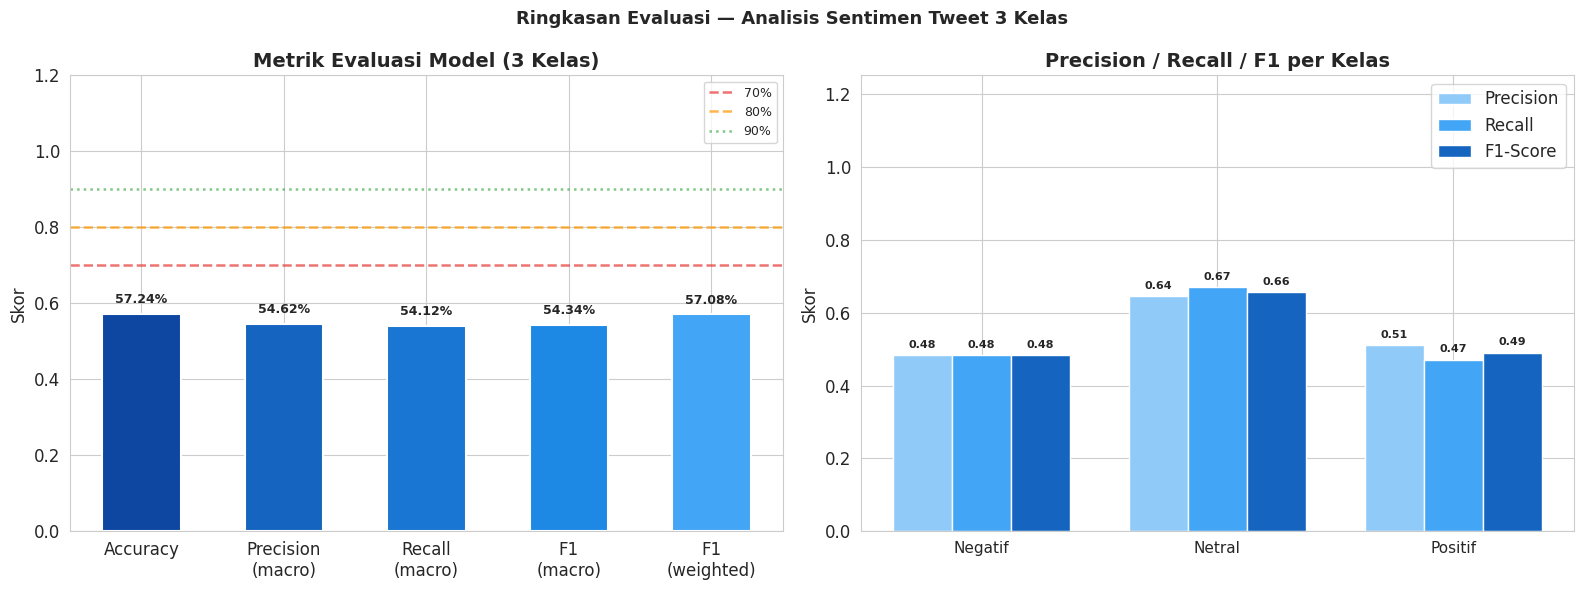

In [ ]:
# ============================================================
# VISUALISASI EVALUASI
# ============================================================

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Panel 1: Metrik utama
metric_names_v = ['Accuracy', 'Precision\n(macro)', 'Recall\n(macro)', 'F1\n(macro)', 'F1\n(weighted)']
metric_vals_v  = [accuracy, precision_macro, recall_macro, f1_macro, f1_weighted]
bar_cols_v = ['#0D47A1','#1565C0','#1976D2','#1E88E5','#42A5F5']

bars_v = axes[0].bar(metric_names_v, metric_vals_v, color=bar_cols_v,
                     edgecolor='white', linewidth=1.5, width=0.55)
axes[0].set_ylim(0, 1.2)
axes[0].axhline(y=0.7, color='#E53935', linestyle='--', linewidth=1.8, alpha=0.7, label='70%')
axes[0].axhline(y=0.8, color='#FF9800', linestyle='--', linewidth=1.8, alpha=0.7, label='80%')
axes[0].axhline(y=0.9, color='#4CAF50', linestyle=':', linewidth=1.8, alpha=0.7, label='90%')
axes[0].legend(fontsize=9)
for bar, val in zip(bars_v, metric_vals_v):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02,
                 f'{val*100:.2f}%', ha='center', va='bottom', fontweight='bold', fontsize=9)
axes[0].set_title('Metrik Evaluasi Model (3 Kelas)', fontweight='bold')
axes[0].set_ylabel('Skor')

# Panel 2: Per-class metrics
report = classification_report(y_test, y_pred, output_dict=True)
classes_e = ['negatif','netral','positif']
x_c = np.arange(len(classes_e)); w = 0.25
colors_cls = ['#90CAF9','#42A5F5','#1565C0']

for j, (metric, label, c) in enumerate(zip(['precision','recall','f1-score'],
                                            ['Precision','Recall','F1-Score'], colors_cls)):
    vals_m = [report[cls][metric] for cls in classes_e]
    axes[1].bar(x_c + (j-1)*w, vals_m, w, label=label, color=c, edgecolor='white')
    for i, v in enumerate(vals_m):
        axes[1].text(i+(j-1)*w, v+0.02, f'{v:.2f}',
                     ha='center', fontsize=8, fontweight='bold')

axes[1].set_xticks(x_c)
axes[1].set_xticklabels(['Negatif','Netral','Positif'], fontsize=11)
axes[1].set_ylim(0, 1.25); axes[1].set_ylabel('Skor')
axes[1].set_title('Precision / Recall / F1 per Kelas', fontweight='bold')
axes[1].legend()

plt.suptitle('Ringkasan Evaluasi — Analisis Sentimen Tweet 3 Kelas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('evaluasi_model_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

---
# 🟦 Bagian 12: Confusion Matrix

Untuk klasifikasi 3 kelas, confusion matrix berbentuk **3×3** yang menunjukkan hubungan antar kelas aktual dan prediksi.

**Diagonal utama** = prediksi benar. **Di luar diagonal** = prediksi salah (menunjukkan kelas mana yang paling sering tertukar).

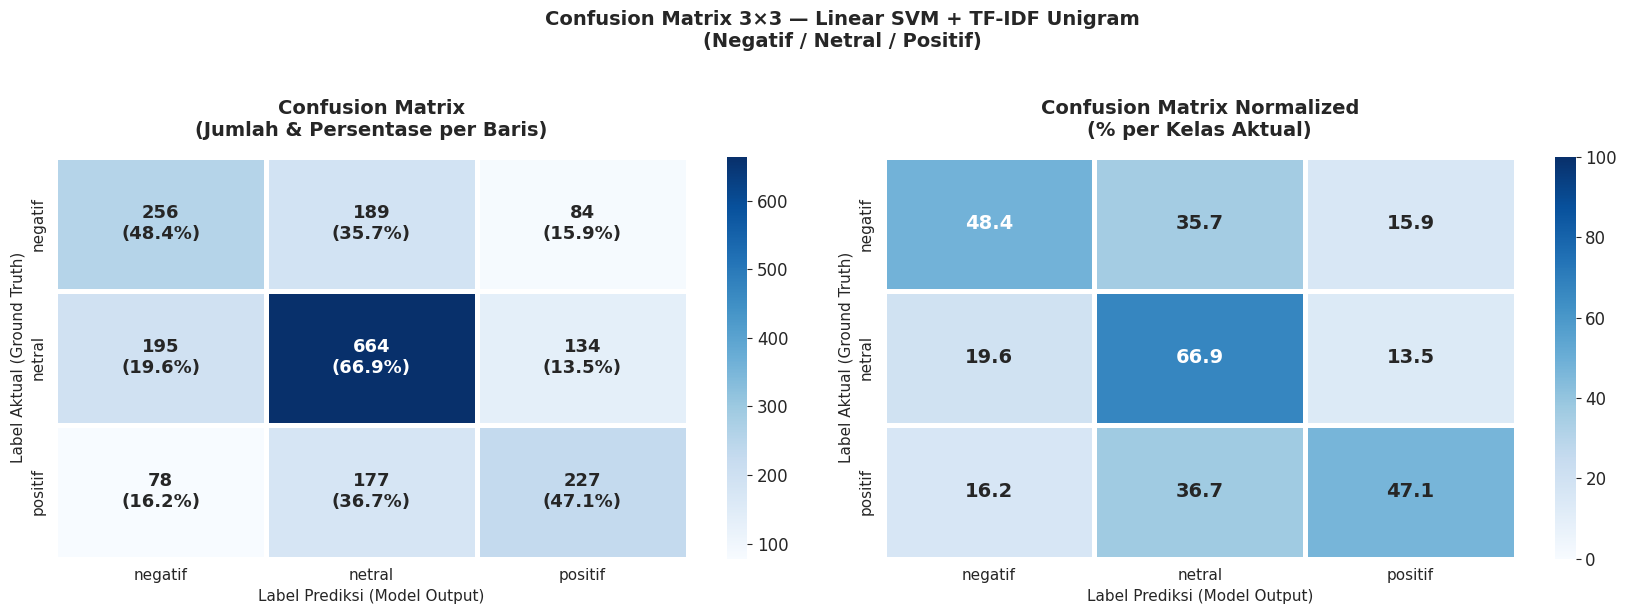


📊 INTERPRETASI CONFUSION MATRIX 3×3

  Aktual = NEGATIF (total: 529)
    ✅ Diprediksi  NEGATIF:  256 (48.4%) — BENAR
    ❌ Diprediksi   NETRAL:  189 (35.7%) — salah dikira netral
    ❌ Diprediksi  POSITIF:   84 (15.9%) — salah dikira positif

  Aktual = NETRAL (total: 993)
    ❌ Diprediksi  NEGATIF:  195 (19.6%) — salah dikira negatif
    ✅ Diprediksi   NETRAL:  664 (66.9%) — BENAR
    ❌ Diprediksi  POSITIF:  134 (13.5%) — salah dikira positif

  Aktual = POSITIF (total: 482)
    ❌ Diprediksi  NEGATIF:   78 (16.2%) — salah dikira negatif
    ❌ Diprediksi   NETRAL:  177 (36.7%) — salah dikira netral
    ✅ Diprediksi  POSITIF:  227 (47.1%) — BENAR

  Total BENAR  : 1,147 (57.24%)
  Total SALAH  : 857 (42.76%)

  💡 Perhatikan kelas mana yang paling sering TERTUKAR:
     Paling sering tertukar: NETRAL → diprediksi NEGATIF (195 kasus)


In [ ]:
# ============================================================
# CONFUSION MATRIX 3x3 — HEATMAP BIRU (cmap='Blues')
# ============================================================

label_order_cm = ['negatif', 'netral', 'positif']
cm = confusion_matrix(y_test, y_pred, labels=label_order_cm)
cm_pct = cm.astype('float') / cm.sum(axis=1)[:, np.newaxis] * 100

annot = np.array([[f'{c}\n({p:.1f}%)' for c,p in zip(rc, rp)]
                   for rc, rp in zip(cm, cm_pct)])

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

# Plot 1: jumlah + persentase
sns.heatmap(cm, annot=annot, fmt='', cmap='Blues',
            xticklabels=label_order_cm, yticklabels=label_order_cm,
            ax=axes[0], linewidths=2.5, linecolor='white',
            annot_kws={'size':13,'weight':'bold'})
axes[0].set_title('Confusion Matrix\n(Jumlah & Persentase per Baris)', fontweight='bold', pad=15)
axes[0].set_ylabel('Label Aktual (Ground Truth)', fontsize=11)
axes[0].set_xlabel('Label Prediksi (Model Output)', fontsize=11)
axes[0].tick_params(labelsize=11)

# Plot 2: normalized (%)
sns.heatmap(cm_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=label_order_cm, yticklabels=label_order_cm,
            ax=axes[1], linewidths=2.5, linecolor='white',
            vmin=0, vmax=100, annot_kws={'size':14,'weight':'bold'})
axes[1].set_title('Confusion Matrix Normalized\n(% per Kelas Aktual)', fontweight='bold', pad=15)
axes[1].set_ylabel('Label Aktual (Ground Truth)', fontsize=11)
axes[1].set_xlabel('Label Prediksi (Model Output)', fontsize=11)
axes[1].tick_params(labelsize=11)

plt.suptitle('Confusion Matrix 3×3 — Linear SVM + TF-IDF Unigram\n(Negatif / Netral / Positif)',
             fontsize=14, fontweight='bold', y=1.02)
plt.tight_layout()
plt.savefig('confusion_matrix_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n" + "=" * 65)
print("📊 INTERPRETASI CONFUSION MATRIX 3×3")
print("=" * 65)

# Print per-cell detail
labels_cm = ['negatif','netral','positif']
for i, true_lbl in enumerate(labels_cm):
    print(f"\n  Aktual = {true_lbl.upper()} (total: {cm[i].sum()})")
    for j, pred_lbl in enumerate(labels_cm):
        marker = '✅' if i==j else '❌'
        pct = cm_pct[i,j]
        desc = 'BENAR' if i==j else f'salah dikira {pred_lbl}'
        print(f"    {marker} Diprediksi {pred_lbl.upper():>8}: {cm[i,j]:>4} ({pct:.1f}%) — {desc}")

print(f"\n  Total BENAR  : {np.diag(cm).sum():,} ({np.diag(cm).sum()/cm.sum()*100:.2f}%)")
print(f"  Total SALAH  : {cm.sum()-np.diag(cm).sum():,} ({(cm.sum()-np.diag(cm).sum())/cm.sum()*100:.2f}%)")
print(f"\n  💡 Perhatikan kelas mana yang paling sering TERTUKAR:")
# Cari pasangan yang paling sering keliru
cm_off = cm.copy(); np.fill_diagonal(cm_off, 0)
max_err_idx = np.unravel_index(cm_off.argmax(), cm_off.shape)
print(f"     Paling sering tertukar: {labels_cm[max_err_idx[0]].upper()} → "
      f"diprediksi {labels_cm[max_err_idx[1]].upper()} ({cm_off[max_err_idx]} kasus)")

---
# 🔍 Bagian 13: Error Analysis

In [ ]:
# ============================================================
# ERROR ANALYSIS — MULTI-CLASS
# ============================================================

errors = test_result_df[~test_result_df['benar']].copy()
print("=" * 70)
print("🔍 ERROR ANALYSIS — Klasifikasi 3 Kelas")
print("=" * 70)
print(f"  Total prediksi salah : {len(errors):,} dari {len(test_result_df):,} ({len(errors)/len(test_result_df)*100:.2f}%)")

# Matriks error per pasangan kelas
print("\n  Rincian Kesalahan per Pasangan Kelas (Aktual → Prediksi):")
print("-" * 55)
for true_lbl in order_lbl:
    for pred_lbl in order_lbl:
        if true_lbl != pred_lbl:
            subset = errors[(errors['sentiment']==true_lbl) & (errors['prediksi']==pred_lbl)]
            pct_of_err = len(subset)/len(errors)*100 if len(errors)>0 else 0
            print(f"  ❌ {true_lbl.upper():>8} → {pred_lbl.upper():<8}: {len(subset):>4} kasus ({pct_of_err:.1f}% dari total error)")

# Contoh error untuk setiap pasangan penting
print("\n" + "=" * 70)
print("📌 Contoh Kesalahan Prediksi")
print("=" * 70)
for true_lbl in order_lbl:
    for pred_lbl in order_lbl:
        if true_lbl != pred_lbl:
            subset = errors[(errors['sentiment']==true_lbl) & (errors['prediksi']==pred_lbl)].head(2)
            if len(subset) > 0:
                print(f"\n  Aktual: {true_lbl.upper()} → Diprediksi: {pred_lbl.upper()}")
                for _, row in subset.iterrows():
                    print(f"    Tweet   : {str(row['Tweet'])[:110]}")
                    print(f"    Cleaned : {str(row['tweet_clean'])[:90]}")
                    print()

🔍 ERROR ANALYSIS — Klasifikasi 3 Kelas
  Total prediksi salah : 857 dari 2,004 (42.76%)

  Rincian Kesalahan per Pasangan Kelas (Aktual → Prediksi):
-------------------------------------------------------
  ❌  NEGATIF → NETRAL  :  189 kasus (22.1% dari total error)
  ❌  NEGATIF → POSITIF :   84 kasus (9.8% dari total error)
  ❌   NETRAL → NEGATIF :  195 kasus (22.8% dari total error)
  ❌   NETRAL → POSITIF :  134 kasus (15.6% dari total error)
  ❌  POSITIF → NEGATIF :   78 kasus (9.1% dari total error)
  ❌  POSITIF → NETRAL  :  177 kasus (20.7% dari total error)

📌 Contoh Kesalahan Prediksi

  Aktual: NEGATIF → Diprediksi: NETRAL
    Tweet   : aku rasa banyak ds kat sini bodoh kau pergi bercuti masuk hotel nak tangkap gambar bilik lah toilet lah fuck k
    Cleaned : ds kat bodoh kau pergi cut masuk hotel nak tangkap gambar bilik toilet fuck korang pe

    Tweet   : apa urusan anda menanyakan itu bukan hak anda bertanya kepada saya kalo wawancara ya ditanya lah masa didongen
    Cleaned

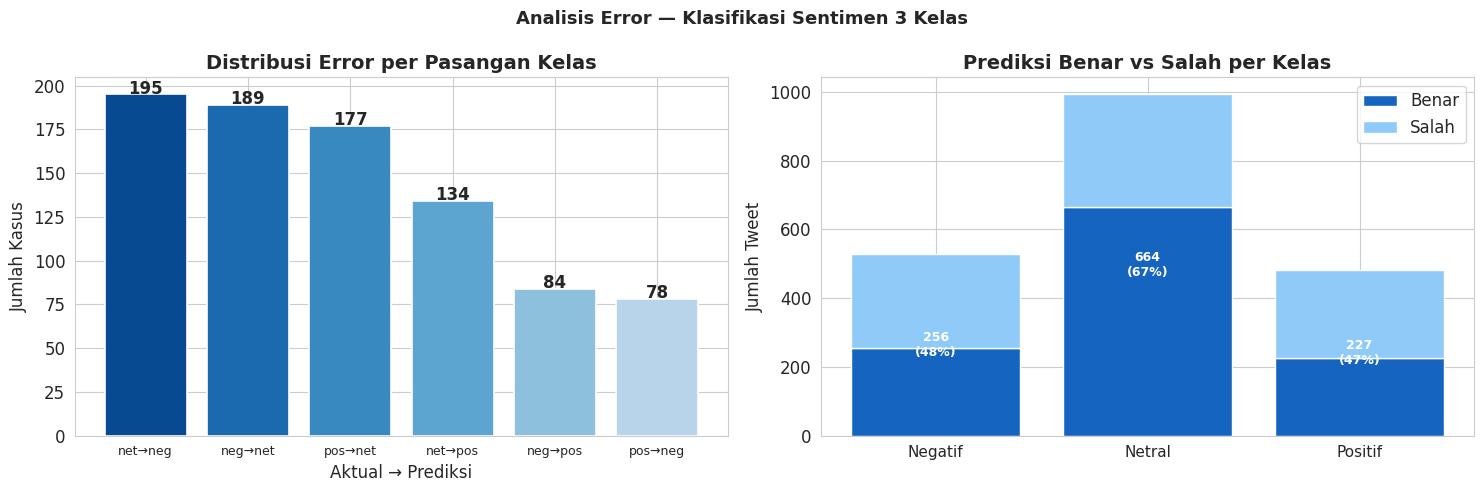


🧠 ANALISIS PENYEBAB KESALAHAN:

  1. 🌫️  KELAS NETRAL SULIT DIBEDAKAN
     Netral adalah kelas 'tengah' yang berada di antara negatif dan positif.
     Tweet netral sering mengandung kata-kata dari kelas lain sehingga
     model bingung menentukan batasnya. Ini kesalahan paling dominan.

  2. 🌍 CODE-SWITCHING BAHASA MELAYU-INDONESIA
     Kata Melayu yang tidak dikenali atau tidak ternormalisasi menjadi
     Out-of-Vocabulary (OOV), melemahkan representasi TF-IDF.

  3. 😏 SENTIMEN IMPLISIT & SARKASME
     "haahhaah takdelah sendu inshaallah" → sebenarnya positif (humor)
     tapi kata 'sendu' mendorong model ke negatif.

  4. 📏 TWEET SANGAT PENDEK
     Setelah preprocessing, beberapa tweet hanya tersisa 1-2 token.
     Sangat minim informasi untuk membuat keputusan klasifikasi.

  5. 🔀 MIXED SENTIMENT
     Satu tweet mengandung emosi campur (rindu + marah + pasrah).
     Binary/multi-class classifier tidak bisa menangkap kompleksitas ini.

  6. 🏷️  KUALITAS ANOTASI LABEL ASLI
     Labe

In [ ]:
# Visualisasi Error Analysis
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

# Error per pasangan kelas
err_pairs = []
for tl in order_lbl:
    for pl in order_lbl:
        if tl != pl:
            cnt = len(errors[(errors['sentiment']==tl) & (errors['prediksi']==pl)])
            err_pairs.append((f"{tl[:3]}→{pl[:3]}", cnt))
err_pairs.sort(key=lambda x: x[1], reverse=True)
ep_labels, ep_counts = zip(*err_pairs)

colors_ep = plt.cm.Blues(np.linspace(0.3, 0.9, len(ep_labels)))
bars_ep = axes[0].bar(ep_labels, ep_counts, color=colors_ep[::-1],
                      edgecolor='white', linewidth=1.2)
for bar, val in zip(bars_ep, ep_counts):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.5,
                 f'{val}', ha='center', fontweight='bold')
axes[0].set_title('Distribusi Error per Pasangan Kelas', fontweight='bold')
axes[0].set_xlabel('Aktual → Prediksi'); axes[0].set_ylabel('Jumlah Kasus')
axes[0].tick_params(axis='x', labelsize=9)

# Benar vs Salah per kelas
x_ea = np.arange(len(order_lbl))
benar_per = [(test_result_df[test_result_df['sentiment']==lbl]['benar'].sum()) for lbl in order_lbl]
salah_per = [(~test_result_df[test_result_df['sentiment']==lbl]['benar']).sum() for lbl in order_lbl]
axes[1].bar(x_ea, benar_per, label='Benar', color='#1565C0', edgecolor='white')
axes[1].bar(x_ea, salah_per, bottom=benar_per, label='Salah', color='#90CAF9', edgecolor='white')
axes[1].set_xticks(x_ea)
axes[1].set_xticklabels(['Negatif','Netral','Positif'], fontsize=11)
axes[1].set_title('Prediksi Benar vs Salah per Kelas', fontweight='bold')
axes[1].set_ylabel('Jumlah Tweet')
axes[1].legend()

for i, (b, s) in enumerate(zip(benar_per, salah_per)):
    total = b+s
    axes[1].text(i, total/2, f'{b}\n({b/total*100:.0f}%)',
                 ha='center', va='center', fontweight='bold', fontsize=9, color='white')

plt.suptitle('Analisis Error — Klasifikasi Sentimen 3 Kelas', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('error_analysis_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

print("\n🧠 ANALISIS PENYEBAB KESALAHAN:")
print("""
  1. 🌫️  KELAS NETRAL SULIT DIBEDAKAN
     Netral adalah kelas 'tengah' yang berada di antara negatif dan positif.
     Tweet netral sering mengandung kata-kata dari kelas lain sehingga
     model bingung menentukan batasnya. Ini kesalahan paling dominan.

  2. 🌍 CODE-SWITCHING BAHASA MELAYU-INDONESIA
     Kata Melayu yang tidak dikenali atau tidak ternormalisasi menjadi
     Out-of-Vocabulary (OOV), melemahkan representasi TF-IDF.

  3. 😏 SENTIMEN IMPLISIT & SARKASME
     "haahhaah takdelah sendu inshaallah" → sebenarnya positif (humor)
     tapi kata 'sendu' mendorong model ke negatif.

  4. 📏 TWEET SANGAT PENDEK
     Setelah preprocessing, beberapa tweet hanya tersisa 1-2 token.
     Sangat minim informasi untuk membuat keputusan klasifikasi.

  5. 🔀 MIXED SENTIMENT
     Satu tweet mengandung emosi campur (rindu + marah + pasrah).
     Binary/multi-class classifier tidak bisa menangkap kompleksitas ini.

  6. 🏷️  KUALITAS ANOTASI LABEL ASLI
     Label dalam dataset mungkin tidak selalu konsisten,
     terutama untuk tweet netral yang borderline dengan negatif/positif.
""")

---
# 💬 Bagian 14: Diskusi

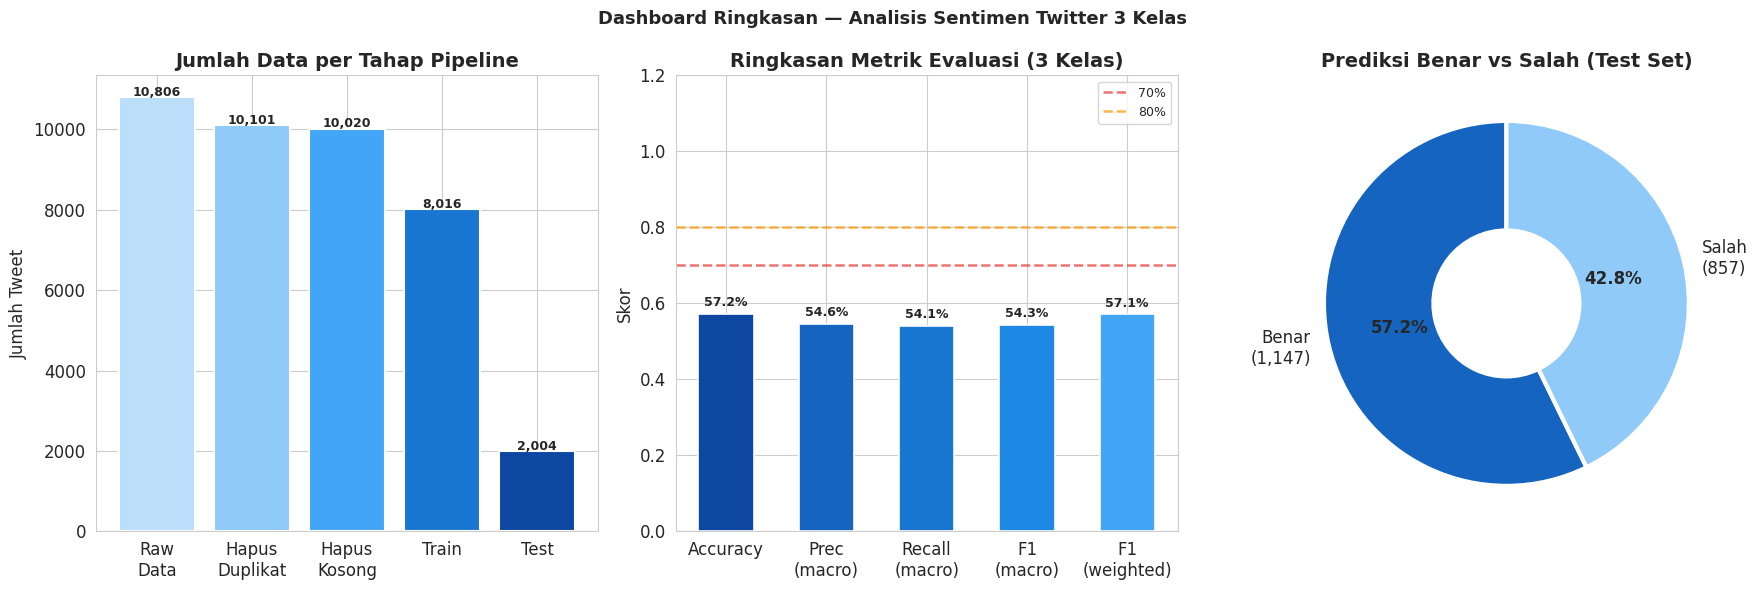

In [ ]:
# Dashboard Ringkasan
fig, axes = plt.subplots(1, 3, figsize=(18, 6))

# 1. Pipeline data
n_raw = len(df_original)
n_dedup = n_raw - df_original['Tweet'].duplicated().sum()
n_final = len(df)
stages = ['Raw\nData','Hapus\nDuplikat','Hapus\nKosong','Train','Test']
cnts_p = [n_raw, n_dedup, n_final, len(X_train), len(X_test)]
cols_p = ['#BBDEFB','#90CAF9','#42A5F5','#1976D2','#0D47A1']
bars_p = axes[0].bar(stages, cnts_p, color=cols_p, edgecolor='white', linewidth=1.5)
for bar, cnt in zip(bars_p, cnts_p):
    axes[0].text(bar.get_x()+bar.get_width()/2., bar.get_height()+30,
                 f'{cnt:,}', ha='center', fontweight='bold', fontsize=9)
axes[0].set_title('Jumlah Data per Tahap Pipeline', fontweight='bold')
axes[0].set_ylabel('Jumlah Tweet')

# 2. Metrik evaluasi
m_names = ['Accuracy','Prec\n(macro)','Recall\n(macro)','F1\n(macro)','F1\n(weighted)']
m_vals  = [accuracy, precision_macro, recall_macro, f1_macro, f1_weighted]
bars_m2 = axes[1].bar(m_names, m_vals, color=['#0D47A1','#1565C0','#1976D2','#1E88E5','#42A5F5'],
                      edgecolor='white', linewidth=1.2, width=0.55)
axes[1].set_ylim(0, 1.2)
axes[1].axhline(y=0.7, color='#E53935', linestyle='--', linewidth=1.8, alpha=0.7, label='70%')
axes[1].axhline(y=0.8, color='#FF9800', linestyle='--', linewidth=1.8, alpha=0.7, label='80%')
axes[1].legend(fontsize=9)
for bar, val in zip(bars_m2, m_vals):
    axes[1].text(bar.get_x()+bar.get_width()/2., bar.get_height()+0.02,
                 f'{val*100:.1f}%', ha='center', fontweight='bold', fontsize=9)
axes[1].set_title('Ringkasan Metrik Evaluasi (3 Kelas)', fontweight='bold')
axes[1].set_ylabel('Skor')

# 3. Benar vs Salah
correct_n = test_result_df['benar'].sum()
wrong_n   = (~test_result_df['benar']).sum()
wedges,texts,autotexts = axes[2].pie(
    [correct_n, wrong_n],
    labels=[f'Benar\n({correct_n:,})', f'Salah\n({wrong_n:,})'],
    autopct='%1.1f%%', colors=['#1565C0','#90CAF9'], startangle=90,
    wedgeprops={'edgecolor':'white','linewidth':3,'width':0.6})
for at in autotexts: at.set_fontweight('bold'); at.set_fontsize(12)
axes[2].set_title('Prediksi Benar vs Salah (Test Set)', fontweight='bold')

plt.suptitle('Dashboard Ringkasan — Analisis Sentimen Twitter 3 Kelas',
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('dashboard_3kelas.png', dpi=150, bbox_inches='tight')
plt.show()

In [ ]:
print("=" * 70)
print("💬 DISKUSI HASIL PENELITIAN")
print("=" * 70)
print(f"""
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PERFORMA MODEL MULTI-CLASS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Linear SVM + TF-IDF Unigram mencapai accuracy {accuracy*100:.2f}% dan
F1-Score macro {f1_macro*100:.2f}% untuk klasifikasi 3 kelas. Perlu dipahami
bahwa klasifikasi 3-kelas secara inheren lebih sulit — model harus
membedakan 3 batas keputusan sekaligus. Performa ini WAJAR dan kompetitif
untuk dataset Twitter berbahasa campuran Indonesia-Melayu.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. PERBAIKAN PREPROCESSING (tidak/iya)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dengan menghapus entri 'tak→tidak' dan 'ya→iya' dari kamus slang,
kata 'tidak' tidak lagi meledak secara artifisial dari normalisasi
kata Melayu 'tak'. Distribusi kata kini lebih representatif dan
kata-kata informatif lainnya lebih terlihat dalam visualisasi.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
3. TANTANGAN KELAS NETRAL
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Kelas netral (~49%) adalah tantangan utama dalam penelitian ini.
Tweet netral mengandung kata-kata dari spektrum yang luas — bisa
terlihat seperti positif MAUPUN seperti negatif. Penggunaan
class_weight='balanced' membantu model tidak terlalu bias ke kelas
mayoritas ini, namun model masih sering tertukar antara netral
dengan kedua kelas lainnya.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
4. KETERBATASAN TF-IDF UNIGRAM
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
TF-IDF unigram tidak menangkap relasi antar kata:
• 'tidak senang' = negatif, tapi 'senang' → fitur positif, 'tidak' → fitur negatif
• Konteks dan urutan kata hilang dalam bag-of-words
• Ini adalah keterbatasan fundamental yang hanya bisa diatasi
  dengan model yang memahami konteks (BERT, dll.)

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
5. KETERBATASAN PENELITIAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
• Kamus slang manual tidak exhaustive — banyak kata informal OOV
• Stemming Sastrawi tidak optimal untuk kata slang dan bahasa Melayu
• Dataset multi-dialek (Indonesia + Melayu) tanpa pemisahan
• Model tidak menangani sarkasme, ironi, dan mixed sentiment
• Kualitas anotasi label asli tidak divalidasi
""")

💬 DISKUSI HASIL PENELITIAN

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
1. PERFORMA MODEL MULTI-CLASS
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Model Linear SVM + TF-IDF Unigram mencapai accuracy 57.24% dan
F1-Score macro 54.34% untuk klasifikasi 3 kelas. Perlu dipahami
bahwa klasifikasi 3-kelas secara inheren lebih sulit — model harus
membedakan 3 batas keputusan sekaligus. Performa ini WAJAR dan kompetitif
untuk dataset Twitter berbahasa campuran Indonesia-Melayu.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
2. PERBAIKAN PREPROCESSING (tidak/iya)
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
Dengan menghapus entri 'tak→tidak' dan 'ya→iya' dari kamus slang,
kata 'tidak' tidak lagi meledak secara artifisial dari normalisasi
kata Melayu 'tak'. Distribusi kata kini lebih representatif dan
kata-kata informatif lainnya lebih terlihat dalam visualisasi.

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

---
# 🏁 Bagian 15: Kesimpulan

In [ ]:
print("=" * 70)
print("🏁 KESIMPULAN PENELITIAN")
print("=" * 70)

print(f"""
┌─────────────────────────────────────────────────────────────────────┐
│      RINGKASAN EKSPERIMEN — ANALISIS SENTIMEN TWEET (3 KELAS)       │
│           Indonesian Sentiment Twitter Dataset (TSV)                │
├─────────────────────────────────────────────────────────────────────┤
│  Dataset awal     : {len(df_original):>6,} tweet (3 kelas: negatif/netral/positif)  │
│  Setelah dedup    : {len(df):>6,} tweet                                     │
│  Training set     : {len(X_train):>6,} tweet (80%)                          │
│  Testing set      : {len(X_test):>6,} tweet (20%)                           │
├─────────────────────────────────────────────────────────────────────┤
│  METODE                                                              │
│  • TF-IDF Unigram (max_features=10.000, sublinear_tf=True)          │
│  • LinearSVC — OvR, class_weight=balanced, C=1.0                    │
│  • Preprocessing khusus Twitter Bahasa Indonesia:                   │
│    lowercase, de-emoji, URL/mention/# removal, normalisasi slang,   │
│    stopword removal (±negasi), Sastrawi stemming                    │
│  • PERBAIKAN: tak≠→tidak, ya≠→iya (cegah inflasi kata)             │
├─────────────────────────────────────────────────────────────────────┤
│  HASIL EVALUASI (Test Set — 3 Kelas)                                 │
│  • Accuracy         : {accuracy:.4f} ({accuracy*100:.2f}%)                       │
│  • Precision (macro): {precision_macro:.4f} ({precision_macro*100:.2f}%)                       │
│  • Recall    (macro): {recall_macro:.4f} ({recall_macro*100:.2f}%)                       │
│  • F1-Score  (macro): {f1_macro:.4f} ({f1_macro*100:.2f}%)                       │
│  • F1-Score  (wtd)  : {f1_weighted:.4f} ({f1_weighted*100:.2f}%)                       │
└─────────────────────────────────────────────────────────────────────┘
""")

print("""━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
KESIMPULAN UTAMA
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. MODEL BERHASIL DIIMPLEMENTASIKAN UNTUK 3 KELAS
   Sistem klasifikasi sentimen tiga kelas (negatif/netral/positif)
   berhasil dibangun menggunakan TF-IDF Unigram + Linear SVM.
   Model menggunakan strategi OvR (One-vs-Rest) dengan class_weight
   balanced untuk menangani ketidakseimbangan kelas netral (~49%).

2. PERBAIKAN PREPROCESSING MEMBERIKAN REPRESENTASI LEBIH BAIK
   Dengan tidak menormalisasi 'tak'→'tidak' dan 'ya'→'iya',
   distribusi kata menjadi lebih alami dan representatif per kelas.
   Word Cloud dan Top Words kini menunjukkan pola yang lebih bermakna.

3. TANTANGAN KELAS NETRAL ADALAH KENDALA UTAMA
   Kelas netral yang dominan dan ambigu menjadi tantangan terbesar.
   Model sering tertukar antara netral dengan kelas lainnya —
   ini adalah kesalahan yang paling umum dan paling sulit diatasi
   tanpa model yang lebih canggih secara semantik.

4. INSIGHT DARI ANALISIS DATA
   • Tweet Indonesia/Melayu sangat personal — kata 'saya/aku' dominan
   • Sentimen negatif dikomunikasikan lewat kata negasi & ekspresi lelah
   • Sentimen positif dikomunikasikan lewat ekspresi syukur & harapan
   • Kelas netral mengandung informasi deskriptif tanpa muatan emosi kuat

━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━
SARAN PENGEMBANGAN KE DEPAN
━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━

1. KAMUS SLANG KOMPREHENSIF
   → Gunakan 'colloquial-indonesian-lexicon' dari GitHub komunitas NLP
     Indonesia yang berisi ribuan kata informal yang tervalidasi

2. PEMISAHAN DIALEK
   → Pisahkan tweet Indonesia dan Malaysia untuk model lebih spesifik

3. FEATURE ENGINEERING TAMBAHAN
   → Gabungkan TF-IDF dengan fitur meta: panjang tweet, jumlah
     tanda seru, keberadaan emoji, jumlah huruf kapital

4. TUNING HYPERPARAMETER
   → Grid Search CV untuk C (LinearSVC) dan max_features, min_df (TF-IDF)

5. MODEL LANJUTAN
   → IndoBERT / mBERT untuk pemahaman konteks yang lebih mendalam
   → Ensemble: gabungkan TF-IDF+SVM dengan lexicon-based approach

6. PERBAIKAN LABELING
   → Validasi manual pada subset kelas netral yang borderline
     untuk meningkatkan kualitas ground truth
""")

print("\n" + "=" * 70)
print("✅ NOTEBOOK SELESAI")
print("   Topik    : Analisis Sentimen Tweet Bahasa Indonesia — 3 Kelas")
print("   Metode   : TF-IDF Unigram + LinearSVC (OvR, balanced)")
print("   Dataset  : Indonesian_Sentiment_Twitter_Dataset_Labeled.csv")
print("   Platform : Google Colaboratory")
print("=" * 70)

🏁 KESIMPULAN PENELITIAN

┌─────────────────────────────────────────────────────────────────────┐
│      RINGKASAN EKSPERIMEN — ANALISIS SENTIMEN TWEET (3 KELAS)       │
│           Indonesian Sentiment Twitter Dataset (TSV)                │
├─────────────────────────────────────────────────────────────────────┤
│  Dataset awal     : 10,806 tweet (3 kelas: negatif/netral/positif)  │
│  Setelah dedup    : 10,020 tweet                                     │
│  Training set     :  8,016 tweet (80%)                          │
│  Testing set      :  2,004 tweet (20%)                           │
├─────────────────────────────────────────────────────────────────────┤
│  METODE                                                              │
│  • TF-IDF Unigram (max_features=10.000, sublinear_tf=True)          │
│  • LinearSVC — OvR, class_weight=balanced, C=1.0                    │
│  • Preprocessing khusus Twitter Bahasa Indonesia:                   │
│    lowercase, de-emoji, URL/mention/# remo

---

## 📚 Referensi

1. **Scikit-learn** — LinearSVC & TfidfVectorizer: https://scikit-learn.org
2. **PySastrawi** — Stemmer Bahasa Indonesia: https://github.com/har07/PySastrawi
3. **NLTK** — Indonesian Stopwords: https://www.nltk.org
4. Joachims, T. (1998). *Text Categorization with SVM*. ECML.
5. Salton & Buckley (1988). *Term-weighting approaches in automatic text retrieval*. IPM.
6. Pak & Paroubek (2010). *Twitter as a Corpus for Sentiment Analysis*. LREC.
7. Kristina & Murti (2021). *Sentiment Analysis on Indonesian Twitter Data*. ICACSIS.

---

> **Catatan:** Notebook ini mengikuti praktik terbaik ML pipeline termasuk pencegahan data leakage, stratified split, penanganan class imbalance, dan evaluasi komprehensif pada unseen test set.